In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import math
import Bio
DF_A = pd.read_csv("A_vs_E.deseq2.results.tsv", sep = '\t')
print(DF_A)

      gene_id      baseMean  log2FoldChange     lfcSE         pvalue  \
0       Q0020   2846.323000       -0.674463  0.417231   6.399530e-02   
1       Q0045   4965.675000        2.296439  1.239693   3.565016e-04   
2       Q0050  97393.600000       -1.486858  0.272632   6.002426e-09   
3       Q0055   9176.751000      -11.521390  0.365692  3.845847e-219   
4       Q0060   1104.390000       -0.297461  0.284158   2.665799e-01   
...       ...           ...             ...       ...            ...   
6392  YPR200C     11.660700       -1.479523  0.650821   1.709386e-03   
6393  YPR201W      6.547552       -0.199252  0.530156   6.351699e-01   
6394  YPR202W      1.681190       -0.323915  0.863129   4.037290e-01   
6395  YPR203W      0.983849        0.025143  0.928803   9.337711e-01   
6396  YPR204W      1.467066       -0.080458  1.082443   6.131790e-01   

               padj  
0      1.190438e-01  
1      1.379378e-03  
2      8.074787e-08  
3     2.343659e-215  
4      3.822442e-01  
...

In [2]:
regulation = [
    (DF_A['log2FoldChange'] > 0) & (DF_A['padj'] < 0.05),
    (DF_A['log2FoldChange'] < 0) & (DF_A['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(regulation, choices, default='NotSign')
print(DF_A)

      gene_id      baseMean  log2FoldChange     lfcSE         pvalue  \
0       Q0020   2846.323000       -0.674463  0.417231   6.399530e-02   
1       Q0045   4965.675000        2.296439  1.239693   3.565016e-04   
2       Q0050  97393.600000       -1.486858  0.272632   6.002426e-09   
3       Q0055   9176.751000      -11.521390  0.365692  3.845847e-219   
4       Q0060   1104.390000       -0.297461  0.284158   2.665799e-01   
...       ...           ...             ...       ...            ...   
6392  YPR200C     11.660700       -1.479523  0.650821   1.709386e-03   
6393  YPR201W      6.547552       -0.199252  0.530156   6.351699e-01   
6394  YPR202W      1.681190       -0.323915  0.863129   4.037290e-01   
6395  YPR203W      0.983849        0.025143  0.928803   9.337711e-01   
6396  YPR204W      1.467066       -0.080458  1.082443   6.131790e-01   

               padj Up/Down_Reg  
0      1.190438e-01     NotSign  
1      1.379378e-03          Up  
2      8.074787e-08        Down  

In [19]:
#Read the .tsv files into python and display them
DF_I = pd.read_csv("I_vs_E.deseq2.results.tsv", sep = '\t')
print(DF_A)

#DF_A - Basic Summary of P-values and Log Fold Changes
DF_I[['log2FoldChange', 'pvalue']].describe()


#DF_A - Identify signficant Up/Downregulation in genes. If fold change above 0 + P-adj below 0.05 then return "Up". If fold change below 0 + P-adj above 0.05 then return "Down".
conditions = [
    (DF_I['log2FoldChange'] > 0) & (DF_I['padj'] < 0.05),
    (DF_I['log2FoldChange'] < 0) & (DF_I['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_I['Up/Down_Reg'] = np.select(conditions, choices, default='NotSign')

      gene_id      baseMean  log2FoldChange     lfcSE         pvalue  \
0       Q0020   2846.323000       -0.674463  0.417231   6.399530e-02   
1       Q0045   4965.675000        2.296439  1.239693   3.565016e-04   
2       Q0050  97393.600000       -1.486858  0.272632   6.002426e-09   
3       Q0055   9176.751000      -11.521390  0.365692  3.845847e-219   
4       Q0060   1104.390000       -0.297461  0.284158   2.665799e-01   
...       ...           ...             ...       ...            ...   
6390  YPR198W    143.394600       -2.122686  0.235922   1.977200e-21   
6391  YPR199C     64.329290       -0.278093  0.240946   2.286189e-01   
6392  YPR200C     11.660700       -1.479523  0.650821   1.709386e-03   
6393  YPR201W      6.547552       -0.199252  0.530156   6.351699e-01   
6394  YPR202W      1.681190       -0.323915  0.863129   4.037290e-01   

               padj Up/Down_Reg  
0      1.190438e-01     NotSign  
1      1.379378e-03          Up  
2      8.074787e-08        Down  

In [20]:
conditions = [
    (DF_A['log2FoldChange'] > 0) & (DF_A['padj'] < 0.05),
    (DF_A['log2FoldChange'] < 0) & (DF_A['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(conditions, choices, default='NotSign')
print(DF_A[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head())

  gene_id  log2FoldChange           padj Up/Down_Reg
0   Q0020       -0.674463   1.190438e-01     NotSign
1   Q0045        2.296439   1.379378e-03          Up
2   Q0050       -1.486858   8.074787e-08        Down
3   Q0055      -11.521390  2.343659e-215        Down
4   Q0060       -0.297461   3.822442e-01     NotSign


In [3]:
DF_A.groupby('Up/Down_Reg').count()
DF_A[['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]

,gene_id,log2FoldChange,pvalue,padj,Up/Down_Reg
0,Q0020,-0.674463,6.399530e-02,1.190438e-01,NotSign
1,Q0045,2.296439,3.565016e-04,1.379378e-03,Up
2,Q0050,-1.486858,6.002426e-09,8.074787e-08,Down
3,Q0055,-11.521390,3.845847e-219,2.343659e-215,Down
4,Q0060,-0.297461,2.665799e-01,3.822442e-01,NotSign
...,...,...,...,...,...
6392,YPR200C,-1.479523,1.709386e-03,5.344792e-03,Down
6393,YPR201W,-0.199252,6.351699e-01,7.355996e-01,NotSign
6394,YPR202W,-0.323915,4.037290e-01,5.250373e-01,NotSign
6395,YPR203W,0.025143,9.337711e-01,NaN,NotSign


In [4]:
DF_A.groupby('Up/Down_Reg').count()

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj
Up/Down_Reg,,,,,,
Down,1405,1405,1405,1405,1405,1405
NotSign,3600,3600,3600,3600,3546,3297
Up,1392,1392,1392,1392,1392,1392


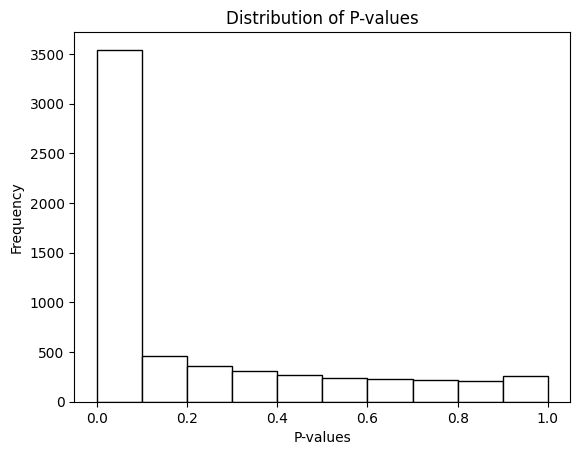

In [21]:
plt.hist(DF_A['pvalue'], bins = 10, color = 'white', edgecolor = 'black')
plt.xlabel('P-values')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.show()

In [6]:
import math
print(log10(DF_A['padj']))


NameError: name 'log10' is not defined

In [7]:
import pandas as pd
import dash_bio
dash_bio.VolcanoPlot(
    dataframe=DF_A,
)

ModuleNotFoundError: No module named 'numpy.compat'

In [ ]:
pip show dash

In [8]:
pip install dash_bio

Note: you may need to restart the kernel to use updated packages.


In [123]:
import pandas as pd
import dash_bio


ModuleNotFoundError: No module named 'numpy.compat'

In [10]:
pip install "dash[cloud]"

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install dash

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install pandas
import dash_bio

SyntaxError: invalid syntax (3775187404.py, line 1)

In [6]:
import dash_bio

ModuleNotFoundError: No module named 'numpy.compat'

In [7]:
#DF_A - Volcano plots to visualize the significance and magnitude of changes in gene expression for each comparison.
##Calculate log10 P-Value
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
##Volcano Plot of Up/Downregulated Genes in DF_A
for i, gene in enumerate (DF_A['gene_id']):
    plt.annotate(gene, (DF_A['log2FoldChange'][i], DF_A['NegLog_Pval'][i]))
    plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()

NameError: name 'np' is not defined

In [5]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


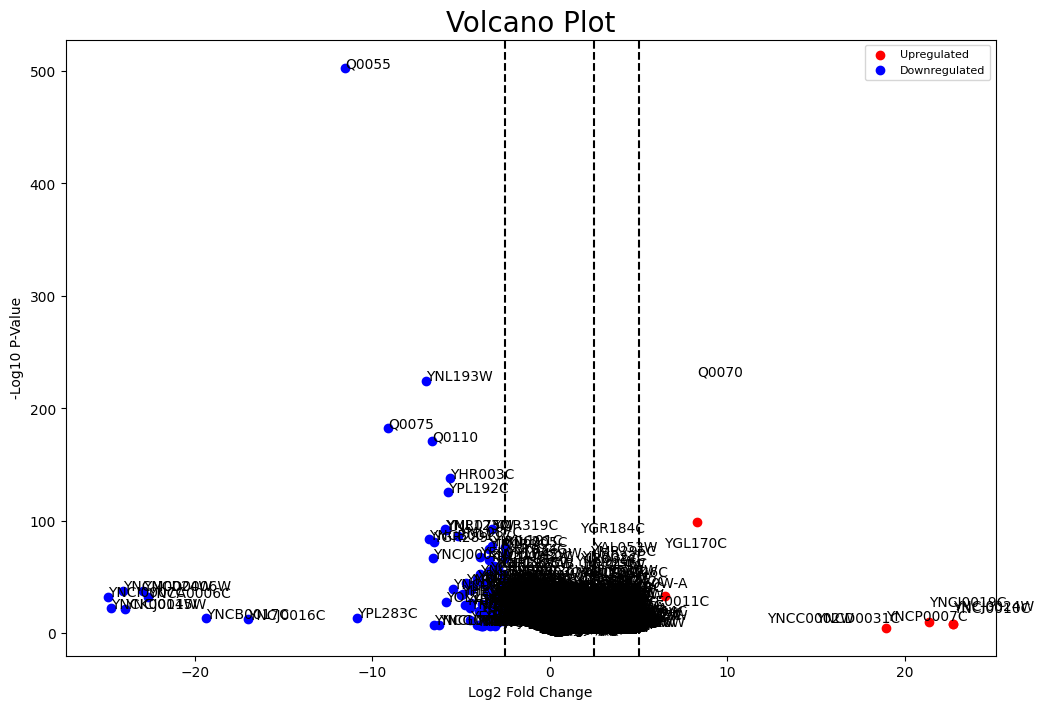

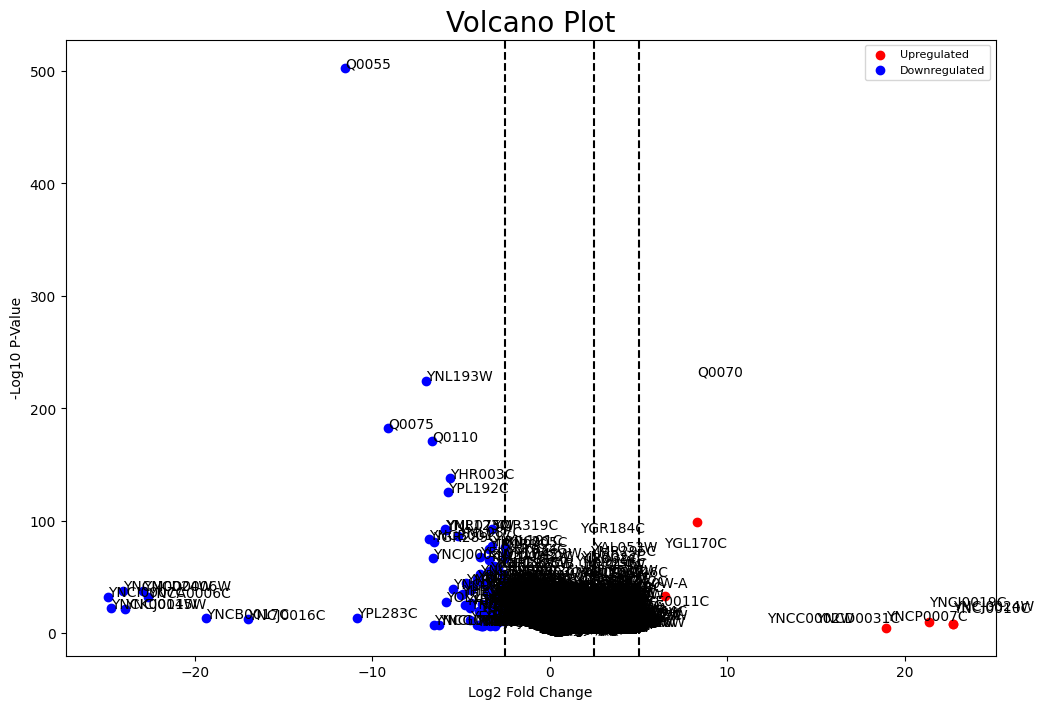

In [6]:
#DF_A - Volcano plots to visualize the significance and magnitude of changes in gene expression for each comparison.
##Calculate log10 P-Value
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
##Volcano Plot of Up/Downregulated Genes in DF_A
for i, gene in enumerate (DF_A['gene_id']):
    plt.annotate(gene, (DF_A['log2FoldChange'][i], DF_A['NegLog_Pval'][i]))
    plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()#DF_A - Volcano plots to visualize the significance and magnitude of changes in gene expression for each comparison.
##Calculate log10 P-Value
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
##Volcano Plot of Up/Downregulated Genes in DF_A
for i, gene in enumerate (DF_A['gene_id']):
    plt.annotate(gene, (DF_A['log2FoldChange'][i], DF_A['NegLog_Pval'][i]))
    plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()

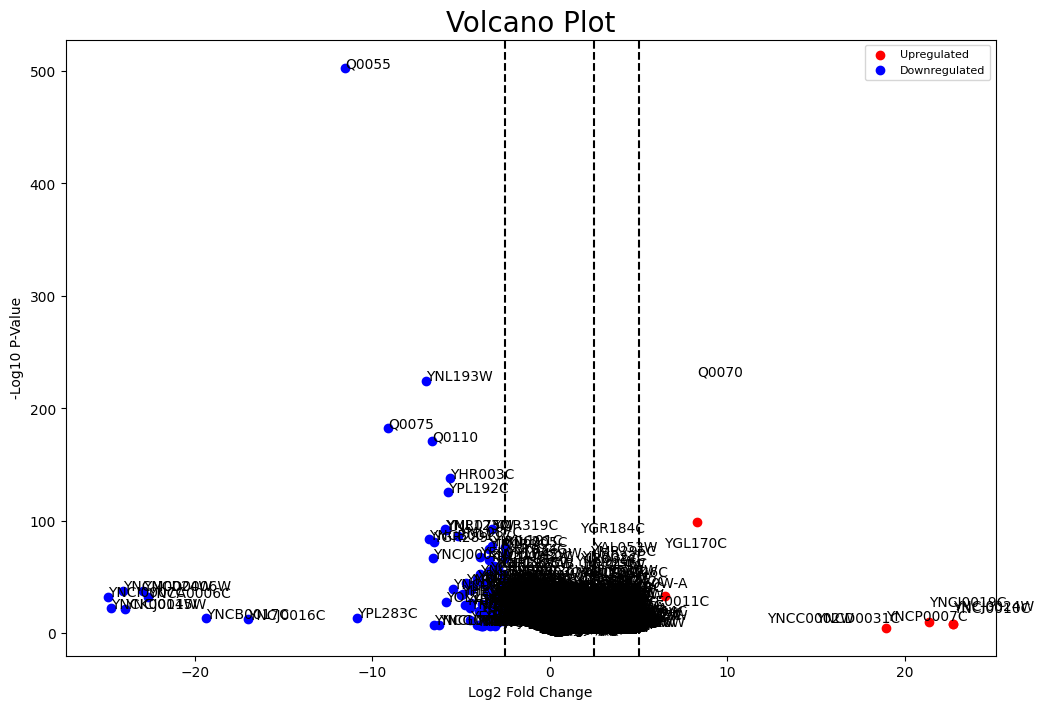

In [10]:
DF_A = pd.read_csv("A_vs_E.deseq2.results.tsv", sep = '\t')

conditions = [
    (DF_A['log2FoldChange'] > 0) & (DF_A['padj'] < 0.05),
    (DF_A['log2FoldChange'] < 0) & (DF_A['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(conditions, choices, default='NotSign')

#DF_A - Volcano plots to visualize the significance and magnitude of changes in gene expression for each comparison.
##Calculate log10 P-Value
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
##Volcano Plot of Up/Downregulated Genes in DF_A
for i, gene in enumerate (DF_A['gene_id']):
    plt.annotate(gene, (DF_A['log2FoldChange'][i], DF_A['NegLog_Pval'][i]))
    plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()


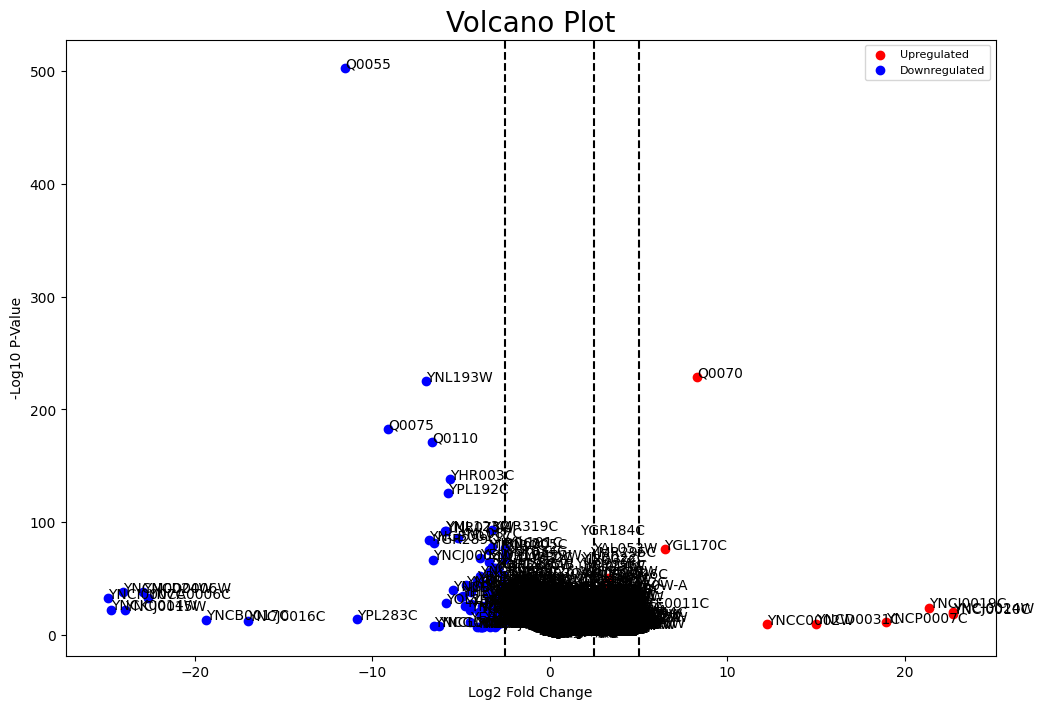

In [11]:
DF_A = pd.read_csv("A_vs_E.deseq2.results.tsv", sep = '\t')

conditions = [
    (DF_A['log2FoldChange'] > 0) & (DF_A['padj'] < 0.05),
    (DF_A['log2FoldChange'] < 0) & (DF_A['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(conditions, choices, default='NotSign')

#DF_A - Volcano plots to visualize the significance and magnitude of changes in gene expression for each comparison.
##Calculate log10 P-Value
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
##Volcano Plot of Up/Downregulated Genes in DF_A
for i, gene in enumerate (DF_A['gene_id']):
    plt.annotate(gene, (DF_A['log2FoldChange'][i], DF_A['NegLog_Pval'][i]))
    plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()

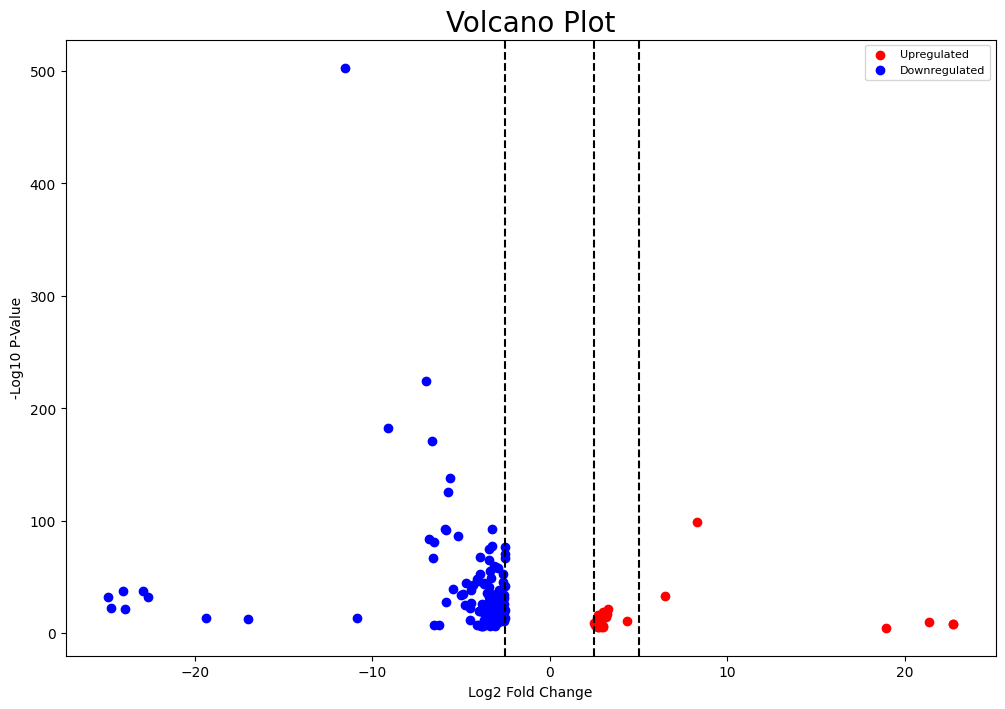

In [14]:
DF_A = pd.read_csv("A_vs_E.deseq2.results.tsv", sep = '\t')

conditions = [
    (DF_A['log2FoldChange'] > 0) & (DF_A['padj'] < 0.05),
    (DF_A['log2FoldChange'] < 0) & (DF_A['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(conditions, choices, default='NotSign')

#DF_A - Volcano plots to visualize the significance and magnitude of changes in gene expression for each comparison.
##Calculate log10 P-Value
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
##Volcano Plot of Up/Downregulated Genes in DF_A
#for i, gene in enumerate (DF_A['gene_id']):
    #plt.annotate(gene, (DF_A['log2FoldChange'][i], DF_A['NegLog_Pval'][i]))
plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()

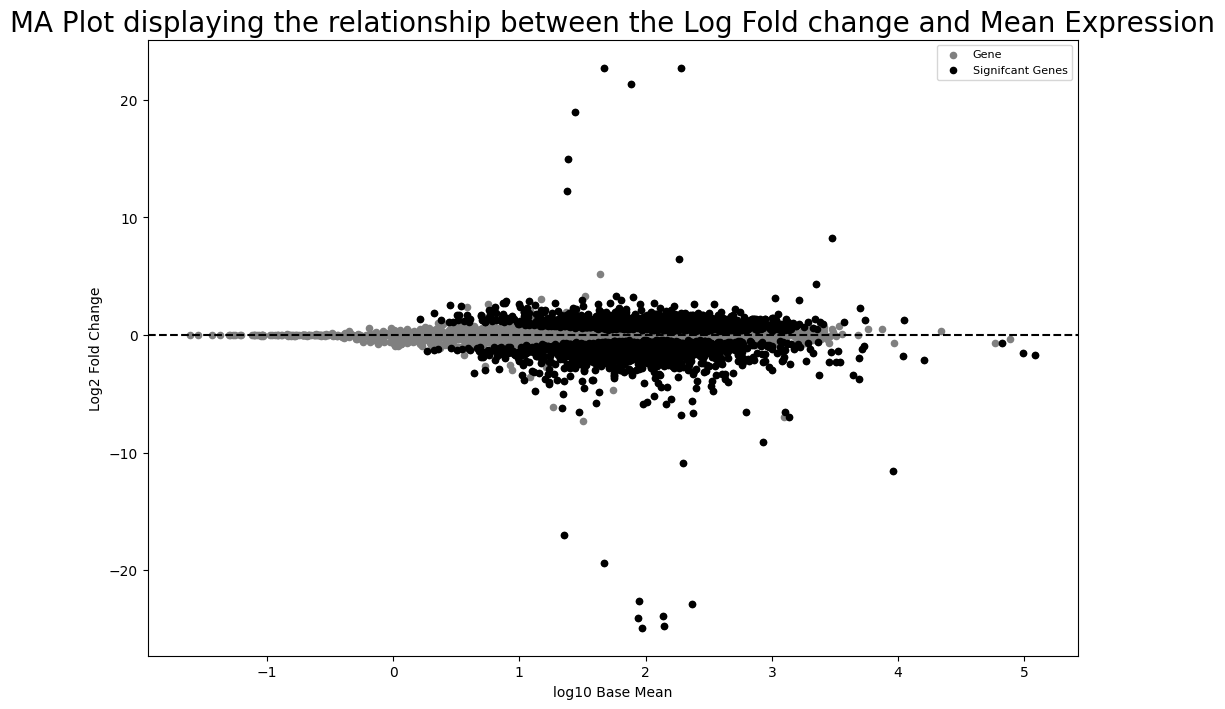

In [36]:
import numpy as np
import matplotlib.pyplot as plt
DF_A['Log_BaseMean'] = np.log10(DF_A['baseMean'])
plt.figure(figsize = (12, 8))
plt.scatter(DF_A['Log_BaseMean'], DF_A['log2FoldChange'],
            color = 'grey', s = 20, label = 'Gene')
plt.scatter(DF_A.loc[DF_A['padj'] < 0.05, 'Log_BaseMean'],
            DF_A.loc[DF_A['padj'] < 0.05, 'log2FoldChange'],
            color = 'black', s = 20, label = 'Signifcant Genes')
plt.title("MA Plot displaying the relationship between the Log Fold change and Mean Expression", fontsize = 20)
plt.xlabel("log10 Base Mean", fontsize = 10)
plt.ylabel("Log2 Fold Change", fontsize = 10)
plt.axhline(0, ls = '--', color = 'black')
plt.legend(loc = 'upper right', fontsize = 8)
plt.show()

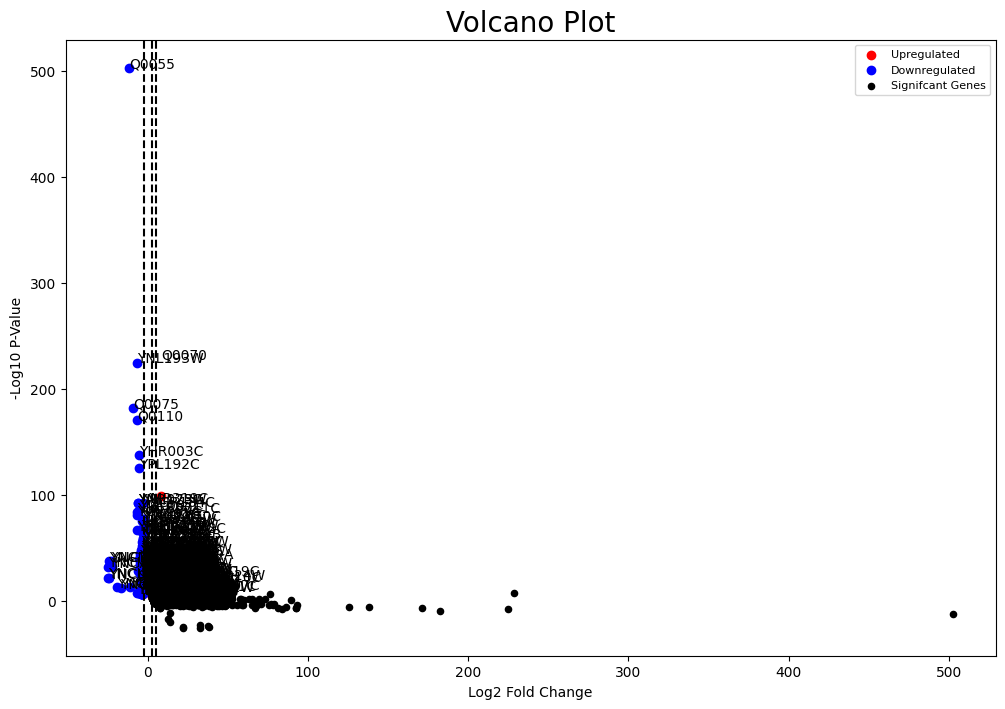

In [37]:
##Calculate log10 P-Value
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
plt.scatter(DF_A.loc[DF_A['padj'] < 0.05, 'NegLog_Pval'],
            DF_A.loc[DF_A['padj'] < 0.05, 'log2FoldChange'],
            color = 'black', s = 20, label = 'Signifcant Genes')
##Volcano Plot of Up/Downregulated Genes in DF_A
for i, gene in enumerate (DF_A['gene_id']):
    plt.annotate(gene, (DF_A['log2FoldChange'][i], DF_A['NegLog_Pval'][i]))
plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()

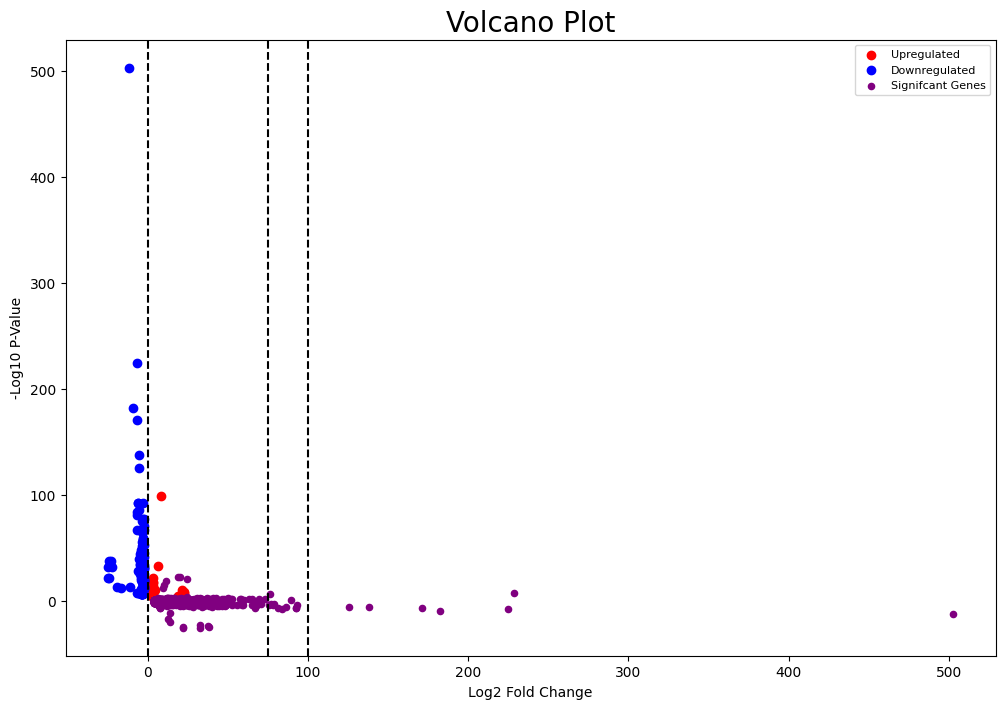

In [44]:
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
plt.scatter(DF_A.loc[DF_A['padj'] < 0.05, 'NegLog_Pval'],
            DF_A.loc[DF_A['padj'] < 0.05, 'log2FoldChange'],
            color = 'purple', s = 20, label = 'Signifcant Genes')

plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(0, ls = '--', color = 'black')
plt.axvline(75, ls = '--', color = 'black')
plt.axvline(100, ls = '--', color = 'black')
plt.show()

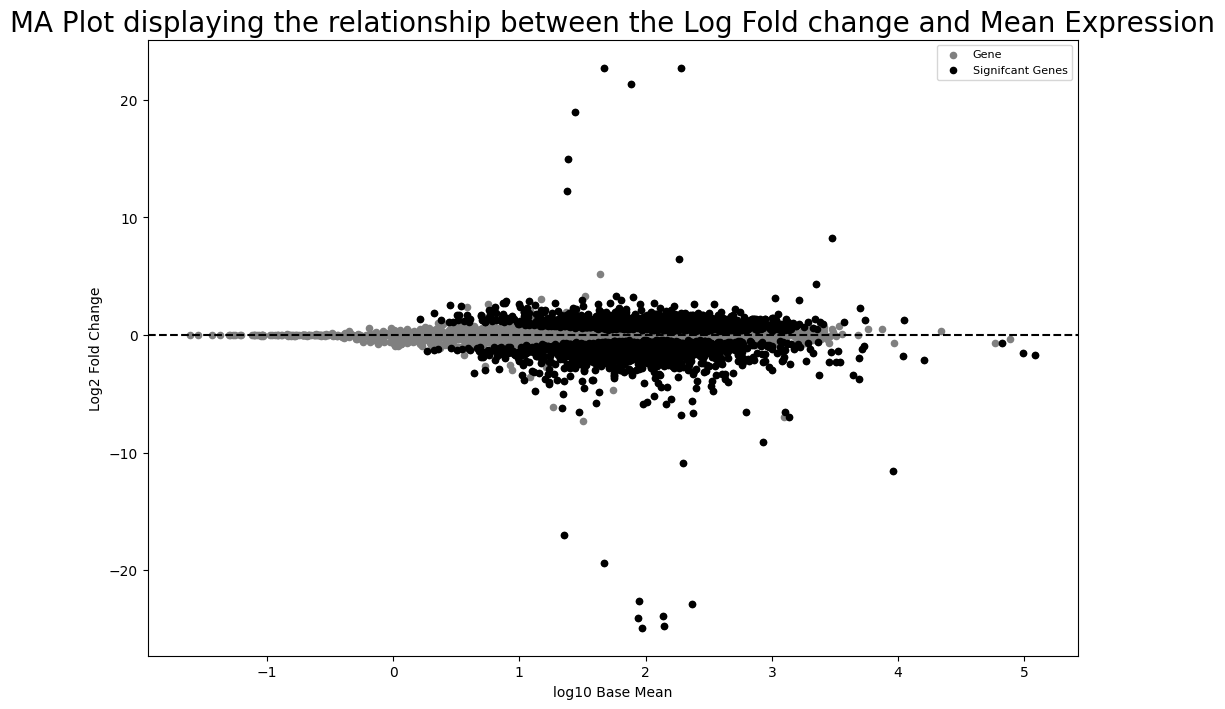

In [45]:
DF_A['Log_BaseMean'] = np.log10(DF_A['baseMean'])
plt.figure(figsize = (12, 8))
plt.scatter(DF_A['Log_BaseMean'], DF_A['log2FoldChange'],
            color = 'grey', s = 20, label = 'Gene')
plt.scatter(DF_A.loc[DF_A['padj'] < 0.05, 'Log_BaseMean'],
            DF_A.loc[DF_A['padj'] < 0.05, 'log2FoldChange'],
            color = 'black', s = 20, label = 'Signifcant Genes')
plt.title("MA Plot displaying the relationship between the Log Fold change and Mean Expression", fontsize = 20)
plt.xlabel("log10 Base Mean", fontsize = 10)
plt.ylabel("Log2 Fold Change", fontsize = 10)
plt.axhline(0, ls = '--', color = 'black')
plt.legend(loc = 'upper right', fontsize = 8)
plt.show()

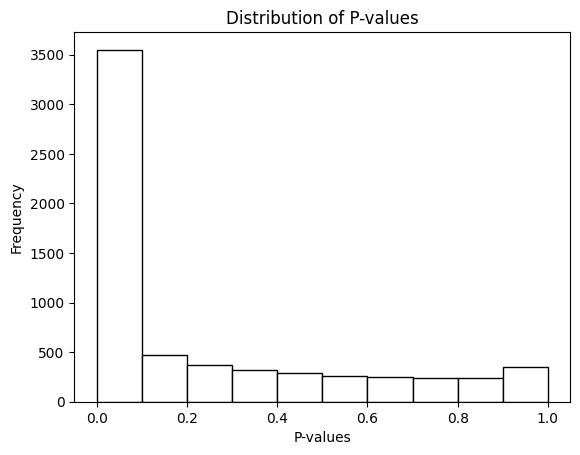

In [46]:
plt.hist(DF_A['pvalue'], bins = 10, color = 'white', edgecolor = 'black')
plt.xlabel('P-values')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.show()


In [64]:
UpReg = DF_A[DF_A['Up/Down_Reg'] == 'Up'][['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
UpReg

,gene_id,log2FoldChange,pvalue,padj,Up/Down_Reg
1,Q0045,2.296439,3.565016e-04,1.379378e-03,Up
6,Q0070,8.290317,5.151415e-100,1.569636e-96,Up
18,Q0250,1.396481,1.423866e-05,7.967895e-05,Up
19,Q0255,3.165602,5.570116e-15,2.672779e-13,Up
47,YAL002W,0.568263,2.470924e-05,1.294738e-04,Up
...,...,...,...,...,...
6359,YPR165W,0.508903,4.112899e-03,1.143431e-02,Up
6363,YPR169W,0.505259,1.723360e-02,3.921642e-02,Up
6367,YPR173C,0.552378,7.635830e-04,2.683550e-03,Up
6373,YPR180W,0.552677,1.948282e-03,5.966248e-03,Up


In [27]:
DF_A

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,NotSign
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,Up
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215,Down
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01,NotSign
...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03,Down
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01,NotSign
6394,YPR202W,1.681190,-0.323915,0.863129,4.037290e-01,5.250373e-01,NotSign
6395,YPR203W,0.983849,0.025143,0.928803,9.337711e-01,NaN,NotSign


In [7]:
DownReg = DF_A[DF_A['Up/Down_Reg'] == 'Down'][['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
DownReg

,gene_id,log2FoldChange,pvalue,padj,Up/Down_Reg
2,Q0050,-1.486858,6.002426e-09,8.074787e-08,Down
3,Q0055,-11.521390,3.845847e-219,2.343659e-215,Down
7,Q0075,-9.092206,6.096362e-80,9.287808e-77,Down
9,Q0085,-1.191215,1.162759e-03,3.839047e-03,Down
10,Q0105,-1.294093,8.190252e-03,2.081376e-02,Down
...,...,...,...,...,...
6384,YPR191W,-1.073127,2.118958e-03,6.395706e-03,Down
6387,YPR194C,-4.302294,1.716014e-19,1.686676e-17,Down
6389,YPR196W,-1.722141,1.220809e-09,1.952653e-08,Down
6390,YPR198W,-2.122686,1.977200e-21,2.409812e-19,Down


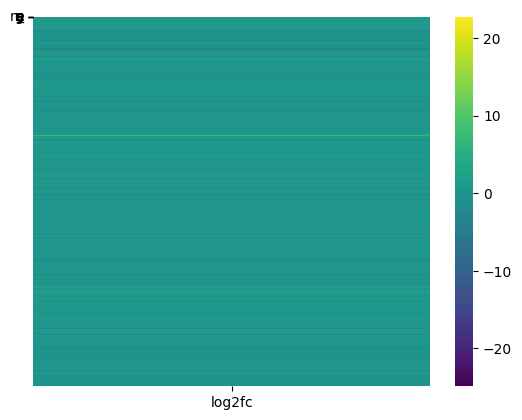

In [8]:
DF_A
import seaborn as sns 
import matplotlib.pyplot as plt 
matrix = DF_A[['log2FoldChange']].values # 2D array for heatmap 
sns.heatmap(matrix, yticklabels='gene_names', xticklabels=["log2fc"], cmap="viridis") 
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import math
import Bio


#Read the .tsv files into python and display them
DF_A = pd.read_csv("A_vs_E.deseq2.results.tsv", sep = '\t')
DF_I = pd.read_csv("I_vs_E.deseq2.results.tsv", sep = '\t')
print(DF_A)
print(DF_I)

      gene_id      baseMean  log2FoldChange     lfcSE         pvalue  \
0       Q0020   2846.323000       -0.674463  0.417231   6.399530e-02   
1       Q0045   4965.675000        2.296439  1.239693   3.565016e-04   
2       Q0050  97393.600000       -1.486858  0.272632   6.002426e-09   
3       Q0055   9176.751000      -11.521390  0.365692  3.845847e-219   
4       Q0060   1104.390000       -0.297461  0.284158   2.665799e-01   
...       ...           ...             ...       ...            ...   
6392  YPR200C     11.660700       -1.479523  0.650821   1.709386e-03   
6393  YPR201W      6.547552       -0.199252  0.530156   6.351699e-01   
6394  YPR202W      1.681190       -0.323915  0.863129   4.037290e-01   
6395  YPR203W      0.983849        0.025143  0.928803   9.337711e-01   
6396  YPR204W      1.467066       -0.080458  1.082443   6.131790e-01   

               padj  
0      1.190438e-01  
1      1.379378e-03  
2      8.074787e-08  
3     2.343659e-215  
4      3.822442e-01  
...

In [10]:
#DF_A - Identify signficant Up/Downregulation in genes. If fold change above 0 + P-adj below 0.05 then return "Up". If fold change below 0 + P-adj above 0.05 then return "Down".
conditions = [
    (DF_A['log2FoldChange'] > 0) & (DF_A['padj'] < 0.05),
    (DF_A['log2FoldChange'] < 0) & (DF_A['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(conditions, choices, default='NotSign')

#Significantly Upregulated and Downregulated genes with their corresponding fold changes, p-values, and adjusted p-values.
print(DF_A[['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']].head())

#DF_I - Identify signficant Up/Downregulation in genes. If fold change above 0 + P-adj below 0.05 then return "Up". If fold change below 0 + P-adj above 0.05 then return "Down".
conditions = [
    (DF_I['log2FoldChange'] > 0) & (DF_I['padj'] < 0.05),
    (DF_I['log2FoldChange'] < 0) & (DF_I['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_I['Up/Down_Reg'] = np.select(conditions, choices, default='NotSign')

#Significantly Upregulated and Downregulated genes with their corresponding fold changes, p-values, and adjusted p-values.
print(DF_I[['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']].head())

  gene_id  log2FoldChange         pvalue           padj Up/Down_Reg
0   Q0020       -0.674463   6.399530e-02   1.190438e-01     NotSign
1   Q0045        2.296439   3.565016e-04   1.379378e-03          Up
2   Q0050       -1.486858   6.002426e-09   8.074787e-08        Down
3   Q0055      -11.521390  3.845847e-219  2.343659e-215        Down
4   Q0060       -0.297461   2.665799e-01   3.822442e-01     NotSign
  gene_id  log2FoldChange        pvalue          padj Up/Down_Reg
0   Q0020       -2.302744  2.566579e-08  1.602344e-07        Down
1   Q0045       -0.976205  1.063241e-01  1.681830e-01     NotSign
2   Q0050       -2.984874  7.808072e-29  1.500806e-26        Down
3   Q0055       -1.730134  1.210130e-06  5.606908e-06        Down
4   Q0060       -1.085074  1.203540e-04  3.849750e-04        Down


In [107]:

#Count the number of Up/Down Regulations and Not Significant in DF_A, Significant Gene List
DF_A.groupby('Up/Down_Reg').count()
##Significantly Upregulated and Downregulated genes with their corresponding fold changes, p-values, and adjusted p-values.
DF_A[['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
##Significantly Upregulated genes will display only
UpReg = DF_A[DF_A['Up/Down_Reg'] == 'Up'][['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
UpReg
##Significantly Downregulated genes will display only
DownReg = DF_A[DF_A['Up/Down_Reg'] == 'Down'][['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
DownReg



,gene_id,log2FoldChange,pvalue,padj,Up/Down_Reg
2,Q0050,-1.486858,6.002426e-09,8.074787e-08,Down
3,Q0055,-11.521390,3.845847e-219,2.343659e-215,Down
7,Q0075,-9.092206,6.096362e-80,9.287808e-77,Down
9,Q0085,-1.191215,1.162759e-03,3.839047e-03,Down
10,Q0105,-1.294093,8.190252e-03,2.081376e-02,Down
...,...,...,...,...,...
6384,YPR191W,-1.073127,2.118958e-03,6.395706e-03,Down
6387,YPR194C,-4.302294,1.716014e-19,1.686676e-17,Down
6389,YPR196W,-1.722141,1.220809e-09,1.952653e-08,Down
6390,YPR198W,-2.122686,1.977200e-21,2.409812e-19,Down


In [6]:
#Count the number of Up/Down Regulations and Not Significant in DF_A, Significant Gene List
DF_I.groupby('Up/Down_Reg').count()
##Significantly Upregulated and Downregulated genes with their corresponding fold changes, p-values, and adjusted p-values.
DF_I[['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
##Significantly Upregulated genes will display only
UpReg = DF_I[DF_I['Up/Down_Reg'] == 'Up'][['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
UpReg
##Significantly Downregulated genes will display only
DownReg = DF_I[DF_I['Up/Down_Reg'] == 'Down'][['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
DownReg

,gene_id,log2FoldChange,pvalue,padj,Up/Down_Reg
0,Q0020,-2.302744,2.566579e-08,1.602344e-07,Down
2,Q0050,-2.984874,7.808072e-29,1.500806e-26,Down
3,Q0055,-1.730134,1.210130e-06,5.606908e-06,Down
4,Q0060,-1.085074,1.203540e-04,3.849750e-04,Down
6,Q0070,-0.735213,5.937684e-03,1.312290e-02,Down
...,...,...,...,...,...
6386,YPR193C,-1.984938,5.350194e-11,5.310842e-10,Down
6387,YPR194C,-3.496768,3.898480e-14,6.926628e-13,Down
6389,YPR196W,-2.633779,3.664795e-19,1.519333e-17,Down
6390,YPR198W,-1.824637,8.536369e-16,1.968952e-14,Down


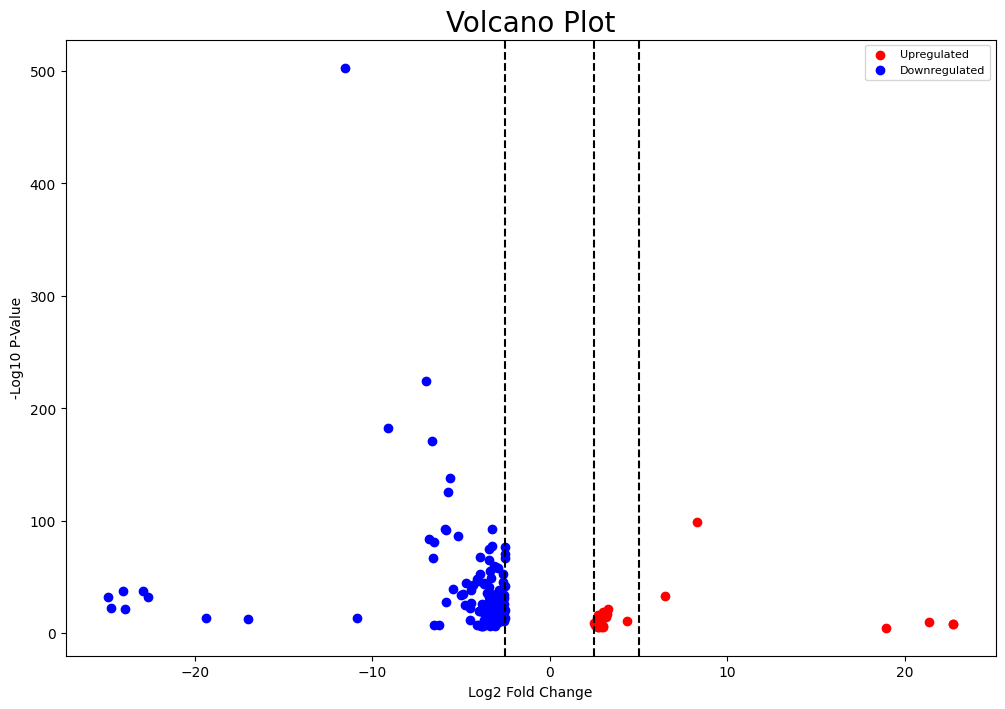

In [7]:
#DF_A - Volcano plots to visualize the significance and magnitude of changes in gene expression for each comparison.
##Calculate log10 P-Value
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
#Indicate Significant genes in Purple-Alter the axvlines for better visualisation
#plt.scatter(DF_A.loc[DF_A['padj'] < 0.05, 'NegLog_Pval'],#
            #DF_A.loc[DF_A['padj'] < 0.05, 'log2FoldChange'],#
            #color = 'purple', s = 20, label = 'Signifcant Genes')#
##Volcano Plot of Up/Downregulated Genes in DF_A
#for i, gene in enumerate (DF_A['gene_id']):
    #plt.annotate(gene, (DF_A['log2FoldChange'][i], DF_A['NegLog_Pval'][i]))
plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()

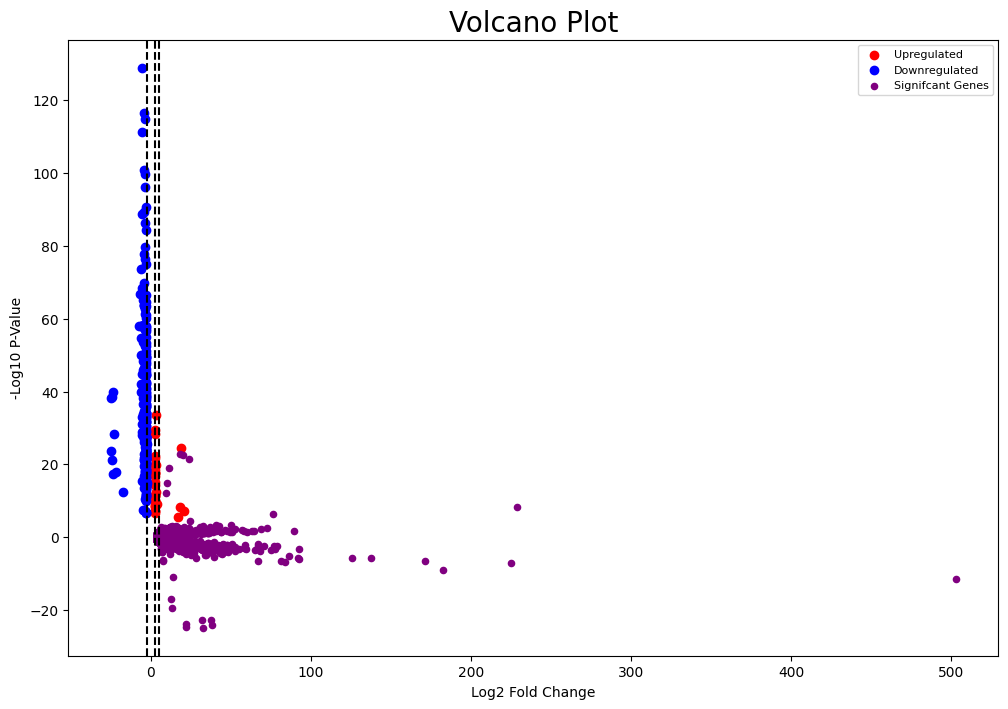

In [115]:

#DF_I - Volcano plots to visualize the significance and magnitude of changes in gene expression for each comparison.
##Calculate log10 P-Value
DF_I['NegLog_Pval'] = -np.log10(DF_I['pvalue'])
plt.figure(figsize = (12, 8))
 #Scatter plot of Upregulated Genes
plt.scatter(DF_I['log2FoldChange'][(DF_I['padj'] < 0.05) & (DF_I['log2FoldChange'] >= 2.5) & (DF_I['NegLog_Pval'] >= 5)],
            DF_I['NegLog_Pval'][(DF_I['padj'] < 0.05) & (DF_I['log2FoldChange'] >= 2.5) & (DF_I['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_I['NegLog_Pval'] = -np.log(DF_I['pvalue'])
plt.scatter(DF_I['log2FoldChange'][(DF_I['padj'] < 0.05) & (DF_I['log2FoldChange'] <= -2.5) & (DF_I['NegLog_Pval'] >= 5)],
            DF_I['NegLog_Pval'][(DF_I['padj'] < 0.05) & (DF_I['log2FoldChange'] <= -2.5) & (DF_I['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')
plt.scatter(DF_A.loc[DF_A['padj'] < 0.05, 'NegLog_Pval'],#
            DF_A.loc[DF_A['padj'] < 0.05, 'log2FoldChange'],#
            color = 'purple', s = 20, label = 'Signifcant Genes')#
##Volcano Plot of Up/Downregulated Genes in DF_I
#for i, gene in enumerate (DF_I['gene_id']):
    #plt.annotate(gene, (DF_I['log2FoldChange'][i], DF_I['NegLog_Pval'][i]))
plt.title('Volcano Plot', fontsize = 20)
plt.xlabel('Log2 Fold Change', fontsize = 10)
plt.ylabel('-Log10 P-Value', fontsize = 10)
plt.legend(loc = 'upper right', fontsize = 8)
plt.axvline(5, ls = '--', color = 'black')
plt.axvline(2.5, ls = '--', color = 'black')
plt.axvline(-2.5, ls = '--', color = 'black')
plt.show()

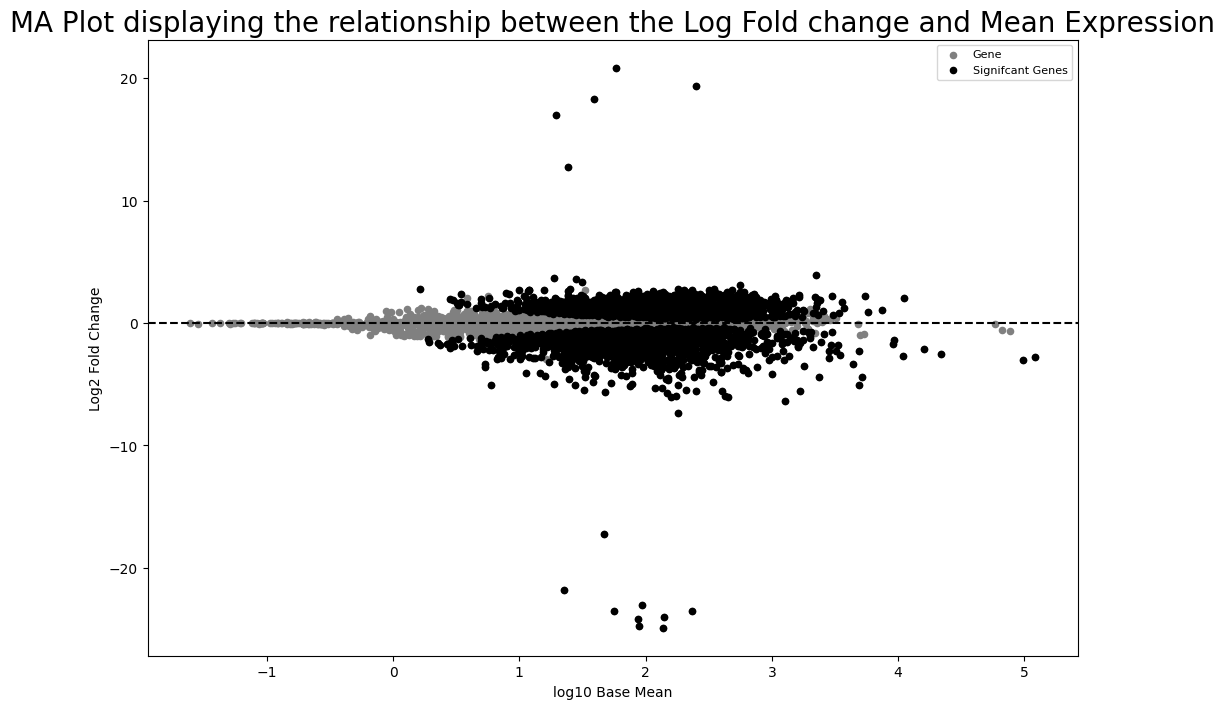

In [113]:

#DF_I - MA Plot to display the relationship between the Log Fold change and Mean Expression for all genes, and significant genes highlighted
DF_I['Log_BaseMean'] = np.log10(DF_I['baseMean'])
plt.figure(figsize = (12, 8))
plt.scatter(DF_I['Log_BaseMean'], DF_I['log2FoldChange'],
            color = 'grey', s = 20, label = 'Gene')
plt.scatter(DF_I.loc[DF_I['padj'] < 0.05, 'Log_BaseMean'],
            DF_I.loc[DF_I['padj'] < 0.05, 'log2FoldChange'],
            color = 'black', s = 20, label = 'Signifcant Genes')
plt.title("MA Plot displaying the relationship between the Log Fold change and Mean Expression", fontsize = 20)
plt.xlabel("log10 Base Mean", fontsize = 10)
plt.ylabel("Log2 Fold Change", fontsize = 10)
plt.axhline(0, ls = '--', color = 'black')
plt.legend(loc = 'upper right', fontsize = 8)
plt.show()

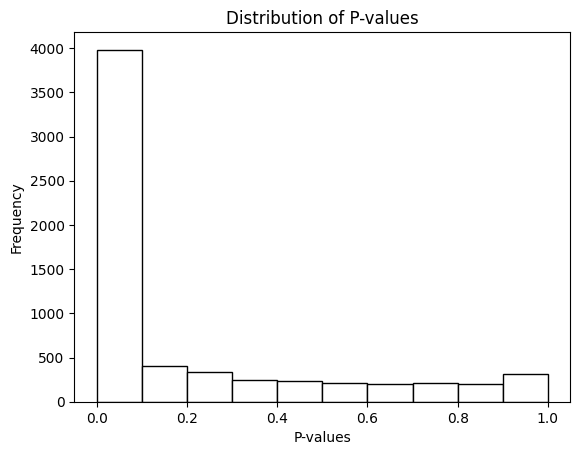

In [32]:

#DF_I - Histogram of P-value Distribution
plt.hist(DF_I['pvalue'], bins = 10, color = 'white', edgecolor = 'black')
plt.xlabel('P-values')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.show()

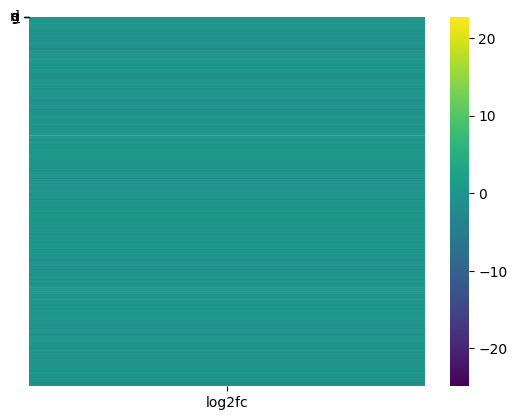

In [11]:
DF_A
import seaborn as sns 
import matplotlib.pyplot as plt 
matrix = DF_A[['log2FoldChange']].values # 2D array for heatmap 
sns.heatmap(matrix, yticklabels= 'gene_id', xticklabels=["log2fc"], cmap="viridis") 
plt.show()

In [12]:
UpReg = DF_I[DF_I['Up/Down_Reg'] == 'Up'][['gene_id', 'log2FoldChange', 'pvalue', 'padj', 'Up/Down_Reg']]
UpReg.head()

,gene_id,log2FoldChange,pvalue,padj,Up/Down_Reg
11,Q0110,1.248008,0.015891,0.031488,Up
19,Q0255,0.911097,0.016732,0.032991,Up
46,YAL001C,0.563379,0.000139,0.000438,Up
47,YAL002W,0.664937,0.000002,0.000007,Up
48,YAL003W,1.460343,0.000006,0.000023,Up


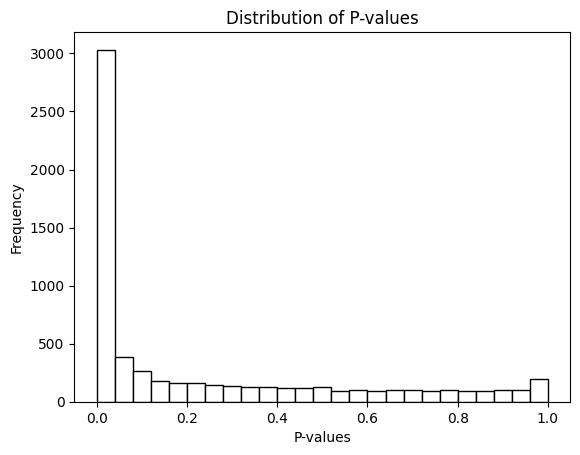

In [18]:
#DF_I - Histogram of P-value Distribution
plt.hist(DF_A['pvalue'], bins = 25, color = 'white', edgecolor = 'black')
plt.xlabel('P-values')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.show()

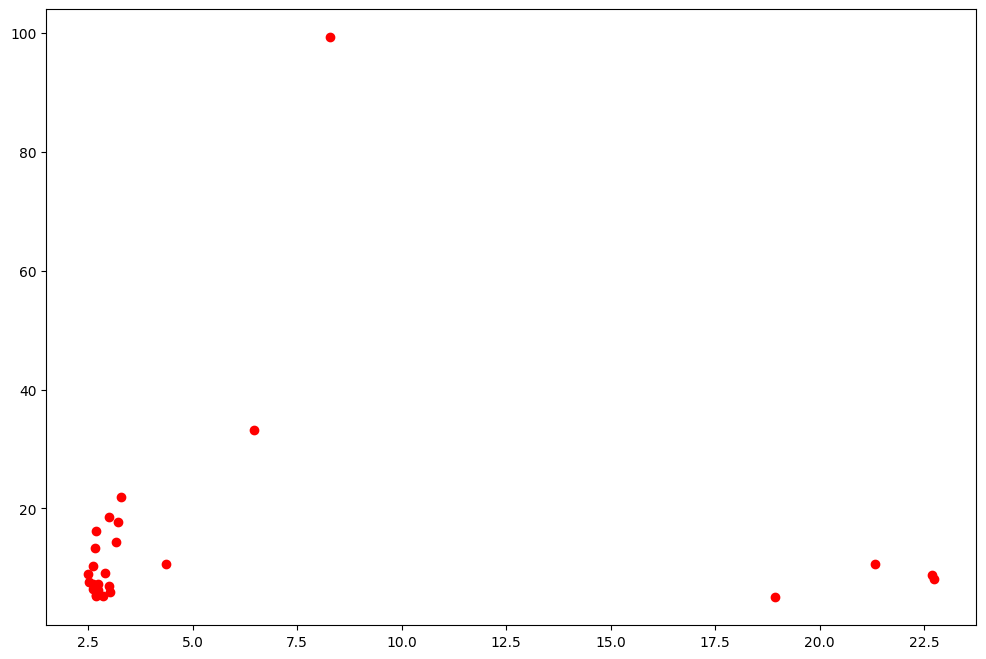

In [21]:
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12, 8))
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')

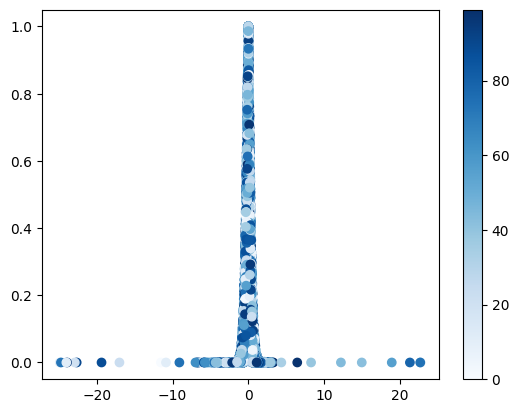

In [13]:
x = (DF_A['log2FoldChange'])
y = (DF_A['pvalue'])
colors = np.random.randint(100, size=(6397))
plt.scatter(x, y, c=colors, cmap='Blues')
plt.colorbar()
plt.show()


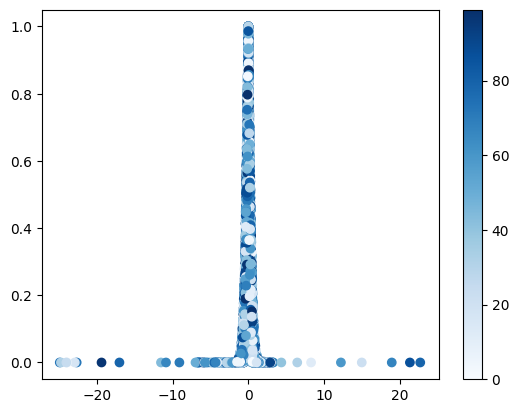

In [23]:
#Summary of p-values and log fold changes across all genes for each comparison.
x = (DF_A['log2FoldChange'])
y = (DF_A['pvalue'])
colors = np.random.randint(100, size=(6397))
plt.scatter(x, y, c=colors, cmap='Blues')
plt.colorbar()
plt.show()

In [14]:
DF_A[['padj', 'log2FoldChange']].describe()

,padj,log2FoldChange
count,6.094000e+03,6397.000000
mean,2.594718e-01,-0.130934
std,3.200505e-01,1.425567
min,2.343659e-215,-24.882900
25%,1.144667e-03,-0.599841
50%,8.282949e-02,-0.024994
75%,4.889770e-01,0.491470
max,1.000000e+00,22.732160


In [15]:
sorted_df = DF_A.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
sorted_df.head(20)


,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
4785,YNCI0010C,46.892810,22.732160,4.071234,7.591811e-09,9.949354e-08,Up
4812,YNCJ0024W,190.418800,22.699530,3.870816,1.676109e-09,2.559952e-08,Up
4807,YNCJ0019C,76.987810,21.335740,3.263297,2.798018e-11,6.558124e-10,Up
4966,YNCP0007C,27.806240,18.940570,7.824438,9.391192e-06,5.567113e-05,Up
4671,YNCD0031C,24.410780,14.981760,10.070923,4.151034e-05,2.065012e-04,Up
4629,YNCC0002W,23.861640,12.229320,10.553447,8.310560e-05,3.805000e-04,Up
6,Q0070,3004.823000,8.290317,0.396236,5.151415e-100,1.569636e-96,Up
2056,YGL170C,184.479300,6.465401,0.556847,7.422143e-34,2.512808e-31,Up
4669,YNCD0029C,43.608500,5.166352,9.222832,NaN,NaN,NotSign
4685,YNCE0011C,2243.171000,4.364310,0.789312,2.131781e-11,5.155189e-10,Up


In [194]:
sorted_df = DF_A.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
print(sorted_df[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15))
mot = sorted_df[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15)
mot

        gene_id  log2FoldChange          padj Up/Down_Reg
4785  YNCI0010C       22.732160  9.949354e-08          Up
4812  YNCJ0024W       22.699530  2.559952e-08          Up
4807  YNCJ0019C       21.335740  6.558124e-10          Up
4966  YNCP0007C       18.940570  5.567113e-05          Up
4671  YNCD0031C       14.981760  2.065012e-04          Up
4629  YNCC0002W       12.229320  3.805000e-04          Up
6         Q0070        8.290317  1.569636e-96          Up
2056    YGL170C        6.465401  2.512808e-31          Up
4669  YNCD0029C        5.166352           NaN     NotSign
4685  YNCE0011C        4.364310  5.155189e-10          Up
4705  YNCF0006W        3.314164           NaN     NotSign
3664    YLL046C        3.298596  1.940327e-20          Up
1628  YER060W-A        3.215959  2.031178e-16          Up
19        Q0255        3.165602  2.672779e-13          Up
4687  YNCE0013W        3.081006           NaN     NotSign


,gene_id,log2FoldChange,padj,Up/Down_Reg
4785,YNCI0010C,22.732160,9.949354e-08,Up
4812,YNCJ0024W,22.699530,2.559952e-08,Up
4807,YNCJ0019C,21.335740,6.558124e-10,Up
4966,YNCP0007C,18.940570,5.567113e-05,Up
4671,YNCD0031C,14.981760,2.065012e-04,Up
4629,YNCC0002W,12.229320,3.805000e-04,Up
6,Q0070,8.290317,1.569636e-96,Up
2056,YGL170C,6.465401,2.512808e-31,Up
4669,YNCD0029C,5.166352,NaN,NotSign
4685,YNCE0011C,4.364310,5.155189e-10,Up


In [16]:
sorted_dfI = DF_I.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
print(sorted_dfI[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15))
mat = sorted_dfI[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15)
mat

        gene_id  log2FoldChange          padj Up/Down_Reg
4809  YNCJ0021C       20.843440  3.789926e-07          Up
1732    YER160C       19.328230  3.608702e-23          Up
4960  YNCP0001C       18.323650  4.254852e-08          Up
4919  YNCN0010C       17.016730  1.016802e-05          Up
4671  YNCD0031C       12.743360  1.554147e-04          Up
4685  YNCE0011C        3.885570  5.517322e-09          Up
4926  YNCN0017W        3.637113  1.855962e-03          Up
4039  YLR363W-A        3.562942  4.595298e-12          Up
5779    YOR242C        3.367956  8.417392e-19          Up
5041    YNL058C        3.121617  1.128776e-31          Up
1677    YER106W        2.796822  1.314941e-08          Up
571     YCL024W        2.771722  1.612625e-17          Up
3802    YLR121C        2.762443  6.863381e-11          Up
1912    YGL015C        2.755330  7.851452e-04          Up
1387    YDR446W        2.726958  3.050120e-07          Up


,gene_id,log2FoldChange,padj,Up/Down_Reg
4809,YNCJ0021C,20.843440,3.789926e-07,Up
1732,YER160C,19.328230,3.608702e-23,Up
4960,YNCP0001C,18.323650,4.254852e-08,Up
4919,YNCN0010C,17.016730,1.016802e-05,Up
4671,YNCD0031C,12.743360,1.554147e-04,Up
4685,YNCE0011C,3.885570,5.517322e-09,Up
4926,YNCN0017W,3.637113,1.855962e-03,Up
4039,YLR363W-A,3.562942,4.595298e-12,Up
5779,YOR242C,3.367956,8.417392e-19,Up
5041,YNL058C,3.121617,1.128776e-31,Up


In [132]:
import seaborn as sns 
import matplotlib.pyplot as plt 
matrix = sorted_df[['log2FoldChange']].values # 2D array for heatmap 
matrix

array([[ 22.73216],
       [ 22.69953],
       [ 21.33574],
       ...,
       [-24.01399],
       [-24.7249 ],
       [-24.8829 ]], shape=(6397, 1))

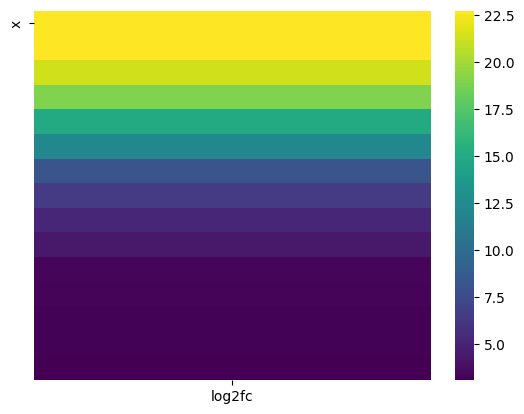

In [50]:

sns.heatmap(mot[['log2FoldChange']],
           vmin=None, vmax=None, yticklabels= 'x', xticklabels=["log2fc"], cmap="viridis") 
plt.show()

AttributeError: 'Axes' object has no attribute 'pivot'

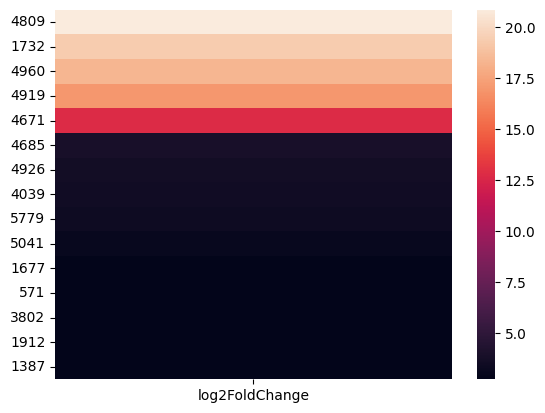

In [62]:

sns.heatmap(mat[['log2FoldChange']]). pivot(index = 'gene id', columns = 'log2FoldChange', values = 'Score', annot='TRUE')

AttributeError: 'Axes' object has no attribute 'pivot'

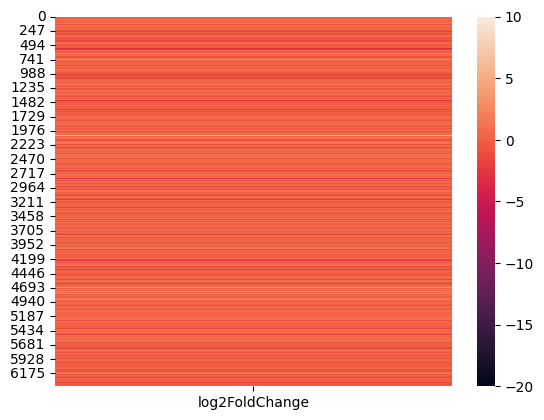

In [78]:

sns.heatmap(DF_A[['log2FoldChange']], vmin=-20, vmax=10). pivot(index = 'gene id', columns = 'log2FoldChange', values = 'Score', annot='TRUE')

No such attribute


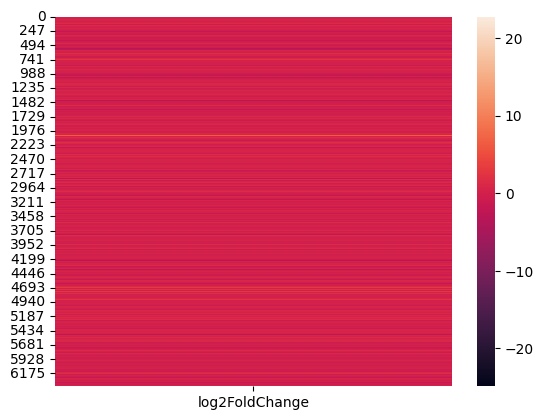

In [75]:
sns.heatmap(DF_A[['log2FoldChange']])
try:
    sns.pivot(index = 'gene id', columns = 'log2FoldChange', values = 'Score', annot='TRUE')
except AttributeError:
    print('No such attribute')
    

No such attribute


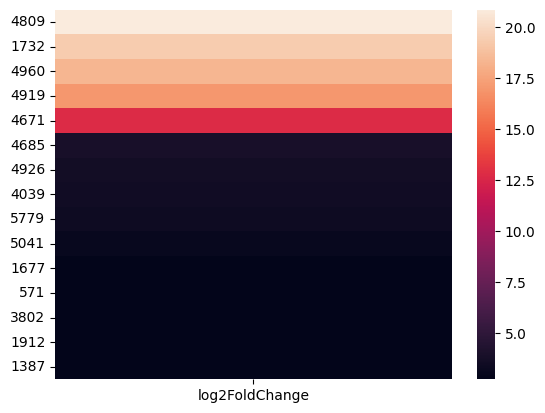

In [71]:
sns.heatmap(mat[['log2FoldChange']])
try:
    sns.pivot(index = 'gene id', columns = 'log2FoldChange', values = 'Score', annot='TRUE')
except AttributeError:
    print('No such attribute')

<Axes: >

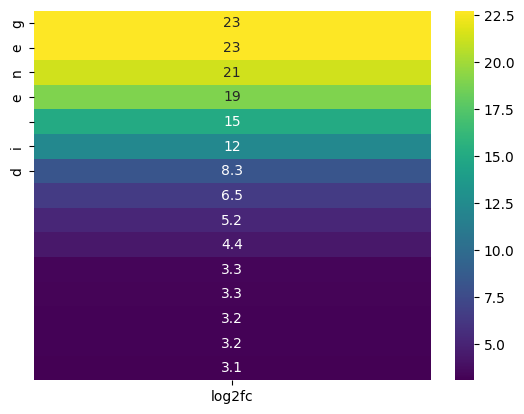

In [105]:
 sns.heatmap(mot[['log2FoldChange']],
            yticklabels = 'gene id', xticklabels = ['log2fc'], annot = True, cmap = 'viridis')

<Axes: >

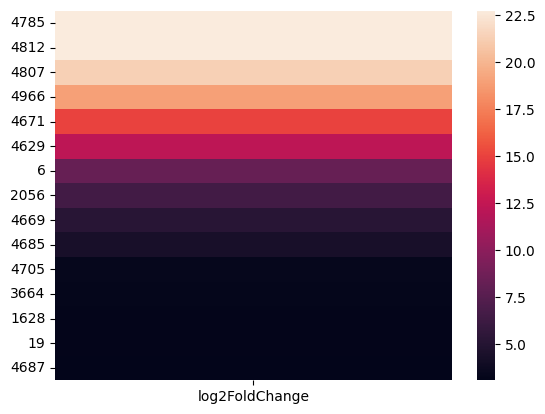

In [156]:
sns.heatmap(mot[['log2FoldChange']])

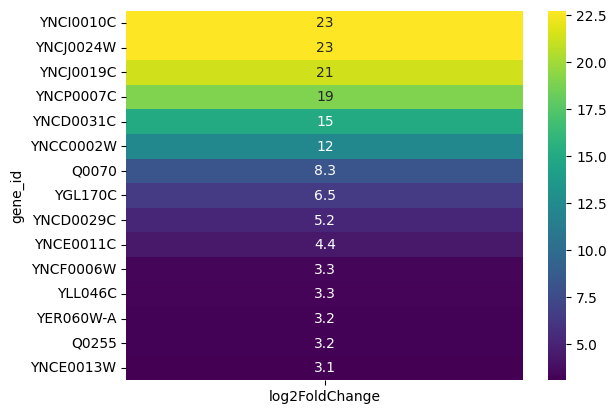

In [158]:
sns.heatmap(mot[['log2FoldChange']].set_index(mot['gene_id']), annot = True, cmap= 'viridis')
plt.show()

In [134]:
mot.isna()

,gene_id,log2FoldChange,padj,Up/Down_Reg
4785,False,False,False,False
4812,False,False,False,False
4807,False,False,False,False
4966,False,False,False,False
4671,False,False,False,False
4629,False,False,False,False
6,False,False,False,False
2056,False,False,False,False
4669,False,False,True,False
4685,False,False,False,False


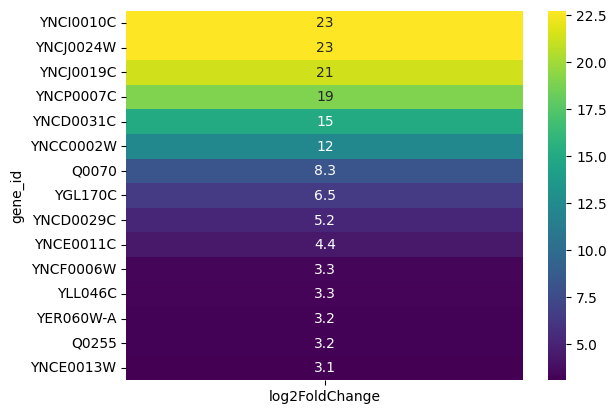

In [140]:
mat = sorted_df[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15)
sns.heatmap(mat[['log2FoldChange']].set_index(mat['gene_id']), annot = True, cmap= 'viridis')
plt.show()

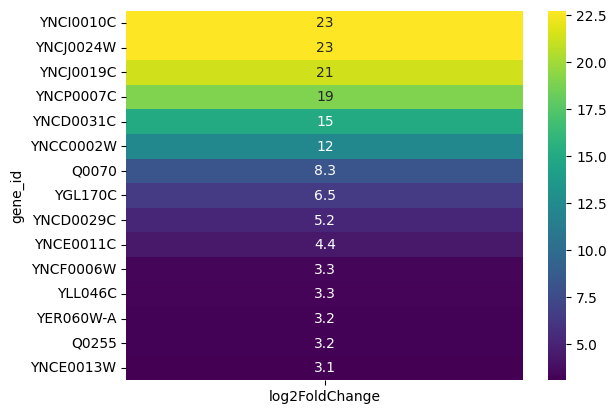

In [142]:
sorted_df = DF_A.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
mat = sorted_df[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15)
sns.heatmap(mat[['log2FoldChange']].set_index(mat['gene_id']), annot = True, cmap= 'viridis')
plt.show()

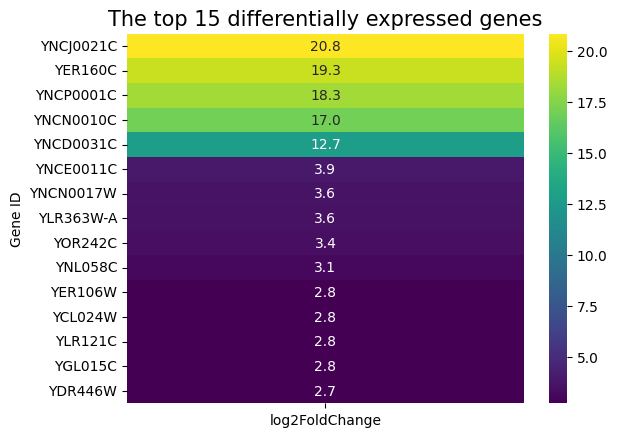

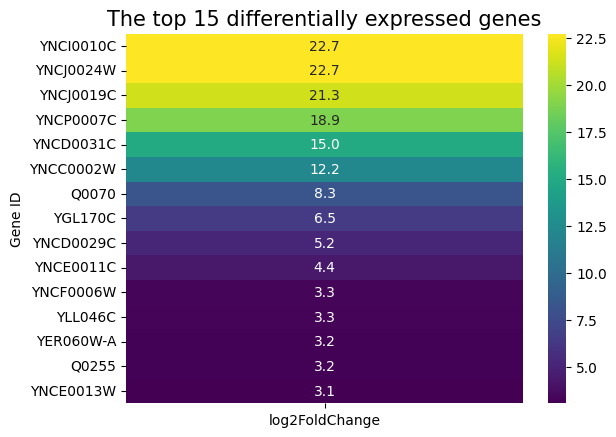

In [185]:
sns.heatmap(mat[['log2FoldChange']].set_index(mat['gene_id']), annot = True, fmt='.1f', cmap= 'viridis')
plt.title("The top 15 differentially expressed genes", fontsize = 15)
plt.ylabel("Gene ID", fontsize = 10)
plt.show()
sns.heatmap(mot[['log2FoldChange']].set_index(mot['gene_id']), annot = True, fmt='.1f', cmap= 'viridis')
plt.title("The top 15 differentially expressed genes", fontsize = 15)
plt.ylabel("Gene ID", fontsize = 10)
plt.show()

In [269]:
#change the name of log2FoldChange into log2fc_a so obv condiiton in heatmap???

renamed_DFA = sorted_df.rename(columns={'log2FoldChange': 'log2fc_a'})
renamed_DFA

,gene_id,baseMean,log2fc_a,lfcSE,pvalue,padj,Up/Down_Reg
4785,YNCI0010C,46.89281,22.73216,4.071234,7.591811e-09,9.949354e-08,Up
4812,YNCJ0024W,190.41880,22.69953,3.870816,1.676109e-09,2.559952e-08,Up
4807,YNCJ0019C,76.98781,21.33574,3.263297,2.798018e-11,6.558124e-10,Up
4966,YNCP0007C,27.80624,18.94057,7.824438,9.391192e-06,5.567113e-05,Up
4671,YNCD0031C,24.41078,14.98176,10.070923,4.151034e-05,2.065012e-04,Up
...,...,...,...,...,...,...,...
4647,YNCD0006W,234.41260,-22.89752,2.750485,3.681924e-17,2.609028e-15,Down
4803,YNCJ0015W,136.51010,-23.92417,3.881110,2.637350e-10,4.855593e-09,Down
4898,YNCM0024W,86.56634,-24.01399,2.878474,2.917983e-17,2.116927e-15,Down
4832,YNCK0014W,140.30120,-24.72490,3.992780,2.094598e-10,3.976473e-09,Down


In [268]:
renamed_DFI = sorted_dfI.rename(columns={'log2FoldChange': 'log2fc_i'})
renamed_DFI

,gene_id,baseMean,log2fc_i,lfcSE,pvalue,padj,Up/Down_Reg
4809,YNCJ0021C,58.65872,20.84344,4.192618,6.584422e-08,3.789926e-07,Up
1732,YER160C,250.22650,19.32823,1.875294,3.698023e-25,3.608702e-23,Up
4960,YNCP0001C,39.10949,18.32365,3.287516,5.998299e-09,4.254852e-08,Up
4919,YNCN0010C,19.64874,17.01673,5.900706,2.332409e-06,1.016802e-05,Up
4671,YNCD0031C,24.41078,12.74336,10.401688,4.515675e-05,1.554147e-04,Up
...,...,...,...,...,...,...,...
4647,YNCD0006W,234.41260,-23.53653,2.750296,4.840985e-18,1.616125e-16,Down
4832,YNCK0014W,140.30120,-24.04255,3.998491,6.546635e-10,5.399910e-09,Down
4898,YNCM0024W,86.56634,-24.17656,2.878653,1.809094e-17,5.543518e-16,Down
4608,YNCA0006C,88.96818,-24.73722,2.957540,2.318951e-17,6.873415e-16,Down


In [242]:
sorted_df = DF_A.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
print(sorted_df[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15))
mot = sorted_df[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15)
mot

        gene_id  log2FoldChange          padj Up/Down_Reg
4785  YNCI0010C       22.732160  9.949354e-08          Up
4812  YNCJ0024W       22.699530  2.559952e-08          Up
4807  YNCJ0019C       21.335740  6.558124e-10          Up
4966  YNCP0007C       18.940570  5.567113e-05          Up
4671  YNCD0031C       14.981760  2.065012e-04          Up
4629  YNCC0002W       12.229320  3.805000e-04          Up
6         Q0070        8.290317  1.569636e-96          Up
2056    YGL170C        6.465401  2.512808e-31          Up
4669  YNCD0029C        5.166352           NaN     NotSign
4685  YNCE0011C        4.364310  5.155189e-10          Up
4705  YNCF0006W        3.314164           NaN     NotSign
3664    YLL046C        3.298596  1.940327e-20          Up
1628  YER060W-A        3.215959  2.031178e-16          Up
19        Q0255        3.165602  2.672779e-13          Up
4687  YNCE0013W        3.081006           NaN     NotSign


,gene_id,log2FoldChange,padj,Up/Down_Reg
4785,YNCI0010C,22.732160,9.949354e-08,Up
4812,YNCJ0024W,22.699530,2.559952e-08,Up
4807,YNCJ0019C,21.335740,6.558124e-10,Up
4966,YNCP0007C,18.940570,5.567113e-05,Up
4671,YNCD0031C,14.981760,2.065012e-04,Up
4629,YNCC0002W,12.229320,3.805000e-04,Up
6,Q0070,8.290317,1.569636e-96,Up
2056,YGL170C,6.465401,2.512808e-31,Up
4669,YNCD0029C,5.166352,NaN,NotSign
4685,YNCE0011C,4.364310,5.155189e-10,Up


In [329]:
renamed_DFI

,gene_id,baseMean,log2fc_i,lfcSE,pvalue,padj,Up/Down_Reg
4809,YNCJ0021C,58.65872,20.84344,4.192618,6.584422e-08,3.789926e-07,Up
1732,YER160C,250.22650,19.32823,1.875294,3.698023e-25,3.608702e-23,Up
4960,YNCP0001C,39.10949,18.32365,3.287516,5.998299e-09,4.254852e-08,Up
4919,YNCN0010C,19.64874,17.01673,5.900706,2.332409e-06,1.016802e-05,Up
4671,YNCD0031C,24.41078,12.74336,10.401688,4.515675e-05,1.554147e-04,Up
...,...,...,...,...,...,...,...
4647,YNCD0006W,234.41260,-23.53653,2.750296,4.840985e-18,1.616125e-16,Down
4832,YNCK0014W,140.30120,-24.04255,3.998491,6.546635e-10,5.399910e-09,Down
4898,YNCM0024W,86.56634,-24.17656,2.878653,1.809094e-17,5.543518e-16,Down
4608,YNCA0006C,88.96818,-24.73722,2.957540,2.318951e-17,6.873415e-16,Down


In [330]:
renamed_DFA

,gene_id,baseMean,log2fc_a,lfcSE,pvalue,padj,Up/Down_Reg
4785,YNCI0010C,46.89281,22.73216,4.071234,7.591811e-09,9.949354e-08,Up
4812,YNCJ0024W,190.41880,22.69953,3.870816,1.676109e-09,2.559952e-08,Up
4807,YNCJ0019C,76.98781,21.33574,3.263297,2.798018e-11,6.558124e-10,Up
4966,YNCP0007C,27.80624,18.94057,7.824438,9.391192e-06,5.567113e-05,Up
4671,YNCD0031C,24.41078,14.98176,10.070923,4.151034e-05,2.065012e-04,Up
...,...,...,...,...,...,...,...
4647,YNCD0006W,234.41260,-22.89752,2.750485,3.681924e-17,2.609028e-15,Down
4803,YNCJ0015W,136.51010,-23.92417,3.881110,2.637350e-10,4.855593e-09,Down
4898,YNCM0024W,86.56634,-24.01399,2.878474,2.917983e-17,2.116927e-15,Down
4832,YNCK0014W,140.30120,-24.72490,3.992780,2.094598e-10,3.976473e-09,Down


In [336]:
#mergeing using on ='gene_id', how = 'inner', (inner is default option) does not return the intended dataframe :( .

merged_df = renamed_DFA.merge(renamed_DFI, how = 'outer')
merged_df

,gene_id,baseMean,log2fc_a,lfcSE,pvalue,padj,Up/Down_Reg,log2fc_i
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,NotSign,NaN
1,Q0020,2846.323000,NaN,0.456351,2.566579e-08,1.602344e-07,Down,-2.302744
2,Q0045,4965.675000,NaN,0.873683,1.063241e-01,1.681830e-01,NotSign,-0.976205
3,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,Up,NaN
4,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down,NaN
...,...,...,...,...,...,...,...,...
12789,tV(UAC)Q,0.330712,NaN,1.192938,9.575679e-01,9.888583e-01,NotSign,0.020931
12790,tW(UCA)Q,0.122614,0.000000,1.065822,1.000000e+00,NaN,NotSign,NaN
12791,tW(UCA)Q,0.122614,NaN,1.294563,1.000000e+00,1.000000e+00,NotSign,0.000000
12792,tY(GUA)Q,1.067754,-0.501022,0.801810,2.479346e-01,NaN,NotSign,NaN


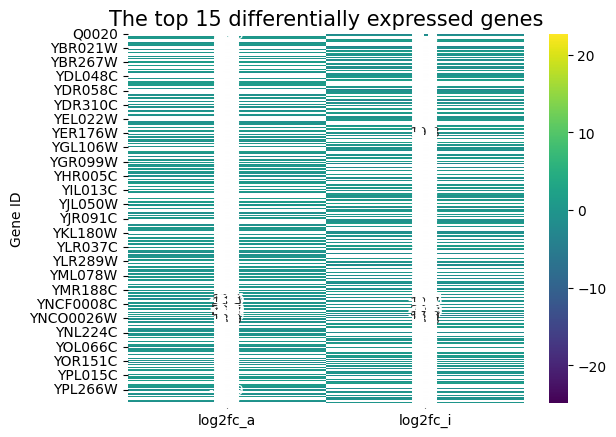

In [337]:
sns.heatmap(merged_df[['log2fc_a', 'log2fc_i']].set_index(merged_df['gene_id']), annot = True, fmt='.1f', cmap= 'viridis')
plt.title("The top 15 differentially expressed genes", fontsize = 15)
plt.ylabel("Gene ID", fontsize = 10)
plt.show()
#only presents the genes which are shared between the two conditions no each conditions top diff expressed genes fml 🥲🥲🥲!!!!

In [356]:
renamed_DFA = renamed_DFA.head(15)
renamed_DFA


,gene_id,baseMean,log2fc_a,lfcSE,pvalue,padj,Up/Down_Reg
4785,YNCI0010C,46.89281,22.732160,4.071234,7.591811e-09,9.949354e-08,Up
4812,YNCJ0024W,190.41880,22.699530,3.870816,1.676109e-09,2.559952e-08,Up
4807,YNCJ0019C,76.98781,21.335740,3.263297,2.798018e-11,6.558124e-10,Up
4966,YNCP0007C,27.80624,18.940570,7.824438,9.391192e-06,5.567113e-05,Up
4671,YNCD0031C,24.41078,14.981760,10.070923,4.151034e-05,2.065012e-04,Up
4629,YNCC0002W,23.86164,12.229320,10.553447,8.310560e-05,3.805000e-04,Up
6,Q0070,3004.82300,8.290317,0.396236,5.151415e-100,1.569636e-96,Up
2056,YGL170C,184.47930,6.465401,0.556847,7.422143e-34,2.512808e-31,Up
4669,YNCD0029C,43.60850,5.166352,9.222832,NaN,NaN,NotSign
4685,YNCE0011C,2243.17100,4.364310,0.789312,2.131781e-11,5.155189e-10,Up


In [357]:
renamed_DFI = renamed_DFI.head(15)
renamed_DFI

,gene_id,baseMean,log2fc_i,lfcSE,pvalue,padj,Up/Down_Reg
4809,YNCJ0021C,58.658720,20.843440,4.192618,6.584422e-08,3.789926e-07,Up
1732,YER160C,250.226500,19.328230,1.875294,3.698023e-25,3.608702e-23,Up
4960,YNCP0001C,39.109490,18.323650,3.287516,5.998299e-09,4.254852e-08,Up
4919,YNCN0010C,19.648740,17.016730,5.900706,2.332409e-06,1.016802e-05,Up
4671,YNCD0031C,24.410780,12.743360,10.401688,4.515675e-05,1.554147e-04,Up
4685,YNCE0011C,2243.171000,3.885570,0.785515,6.706378e-10,5.517322e-09,Up
4926,YNCN0017W,18.951210,3.637113,7.094550,6.770765e-04,1.855962e-03,Up
4039,YLR363W-A,27.917670,3.562942,0.567571,3.028274e-13,4.595298e-12,Up
5779,YOR242C,31.560920,3.367956,0.395381,1.552633e-20,8.417392e-19,Up
5041,YNL058C,558.932300,3.121617,0.267326,3.381168e-34,1.128776e-31,Up


In [364]:
merged_df101 = renamed_DFA.merge(renamed_DFI, how = 'outer')
merged_df101.head(45)

,gene_id,baseMean,log2fc_a,lfcSE,pvalue,padj,Up/Down_Reg,log2fc_i
0,Q0070,3004.823000,8.290317,0.396236,5.151415e-100,1.569636e-96,Up,NaN
1,Q0255,1065.918000,3.165602,0.450088,5.570116e-15,2.672779e-13,Up,NaN
2,YCL024W,181.785800,NaN,0.329044,3.915249e-19,1.612625e-17,Up,2.771722
3,YDR446W,9.910044,NaN,0.594644,5.198140e-08,3.050120e-07,Up,2.726958
4,YER060W-A,79.194160,3.215959,0.398738,2.333155e-18,2.031178e-16,Up,NaN
5,YER106W,25.128120,NaN,0.536682,1.699908e-09,1.314941e-08,Up,2.796822
6,YER160C,250.226500,NaN,1.875294,3.698023e-25,3.608702e-23,Up,19.328230
7,YGL015C,1.641030,NaN,1.329948,2.608073e-04,7.851452e-04,Up,2.755330
8,YGL170C,184.479300,6.465401,0.556847,7.422143e-34,2.512808e-31,Up,NaN
9,YLL046C,58.127380,3.298596,0.358751,1.400958e-22,1.940327e-20,Up,NaN


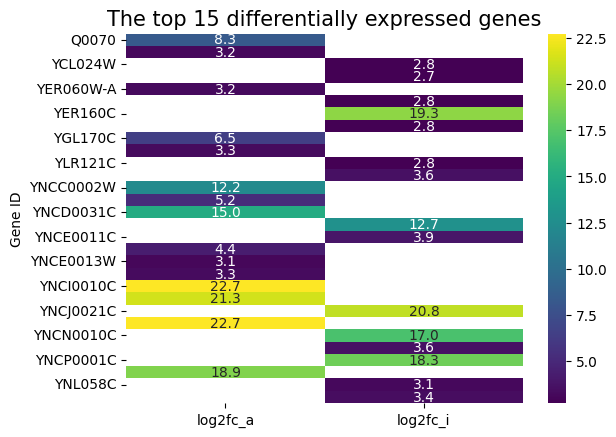

In [361]:
sns.heatmap(merged_df101[['log2fc_a', 'log2fc_i']].set_index(merged_df101['gene_id']), annot = True, fmt='.1f', cmap= 'viridis')
plt.title("The top 15 differentially expressed genes", fontsize = 15)
plt.ylabel("Gene ID", fontsize = 10)
plt.show()

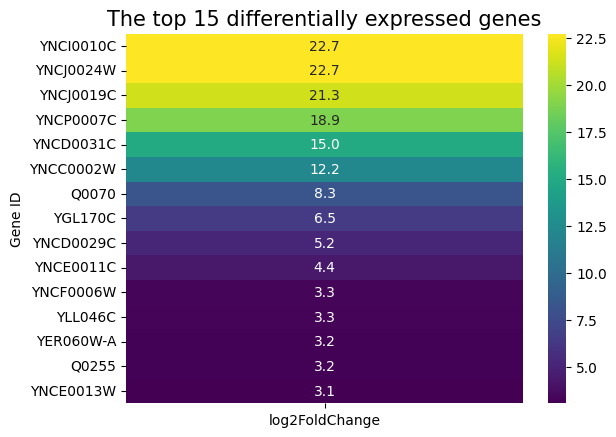

In [365]:
sorted_df = DF_A.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
mat = sorted_df[['gene_id', 'log2FoldChange', 'padj', 'Up/Down_Reg']].head(15)
#Display a Heatmap of the top 15 differentially expressed genes, graph is annotated with log2fc data, 'fmt=".1f"' displays results to 1 decimal point, rather than rounded (Seaborn website).
sns.heatmap(mat[['log2FoldChange']].set_index(mat['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top 15 differentially expressed genes", fontsize = 15)
plt.ylabel("Gene ID", fontsize = 10)
plt.show()


In [27]:
sorted_dfI=sorted_dfI.head(11)


In [28]:
sorted_df=sorted_df.head(11)

In [31]:
sorted_df = sorted_df.rename(columns={'log2FoldChange': 'log2fc_A'})
sorted_df

,gene_id,baseMean,log2fc_A,lfcSE,pvalue,padj,Up/Down_Reg
4785,YNCI0010C,46.89281,22.732160,4.071234,7.591811e-09,9.949354e-08,Up
4812,YNCJ0024W,190.41880,22.699530,3.870816,1.676109e-09,2.559952e-08,Up
4807,YNCJ0019C,76.98781,21.335740,3.263297,2.798018e-11,6.558124e-10,Up
4966,YNCP0007C,27.80624,18.940570,7.824438,9.391192e-06,5.567113e-05,Up
4671,YNCD0031C,24.41078,14.981760,10.070923,4.151034e-05,2.065012e-04,Up
4629,YNCC0002W,23.86164,12.229320,10.553447,8.310560e-05,3.805000e-04,Up
6,Q0070,3004.82300,8.290317,0.396236,5.151415e-100,1.569636e-96,Up
2056,YGL170C,184.47930,6.465401,0.556847,7.422143e-34,2.512808e-31,Up
4669,YNCD0029C,43.60850,5.166352,9.222832,NaN,NaN,NotSign
4685,YNCE0011C,2243.17100,4.364310,0.789312,2.131781e-11,5.155189e-10,Up


In [32]:
sorted_dfI = sorted_dfI.rename(columns={'log2FoldChange': 'log2fc_I'})
sorted_dfI

,gene_id,baseMean,log2fc_I,lfcSE,pvalue,padj,Up/Down_Reg
4809,YNCJ0021C,58.65872,20.843440,4.192618,6.584422e-08,3.789926e-07,Up
1732,YER160C,250.22650,19.328230,1.875294,3.698023e-25,3.608702e-23,Up
4960,YNCP0001C,39.10949,18.323650,3.287516,5.998299e-09,4.254852e-08,Up
4919,YNCN0010C,19.64874,17.016730,5.900706,2.332409e-06,1.016802e-05,Up
4671,YNCD0031C,24.41078,12.743360,10.401688,4.515675e-05,1.554147e-04,Up
4685,YNCE0011C,2243.17100,3.885570,0.785515,6.706378e-10,5.517322e-09,Up
4926,YNCN0017W,18.95121,3.637113,7.094550,6.770765e-04,1.855962e-03,Up
4039,YLR363W-A,27.91767,3.562942,0.567571,3.028274e-13,4.595298e-12,Up
5779,YOR242C,31.56092,3.367956,0.395381,1.552633e-20,8.417392e-19,Up
5041,YNL058C,558.93230,3.121617,0.267326,3.381168e-34,1.128776e-31,Up


In [40]:
sorted_df.append(sorted_dfI, ignore_index=True)

AttributeError: 'DataFrame' object has no attribute 'append'

In [42]:
MERGED = pd.concat([sorted_df, sorted_dfI], ignore_index=True)
MERGED


,gene_id,baseMean,log2fc_A,lfcSE,pvalue,padj,Up/Down_Reg,log2fc_I
0,YNCI0010C,46.89281,22.732160,4.071234,7.591811e-09,9.949354e-08,Up,NaN
1,YNCJ0024W,190.41880,22.699530,3.870816,1.676109e-09,2.559952e-08,Up,NaN
2,YNCJ0019C,76.98781,21.335740,3.263297,2.798018e-11,6.558124e-10,Up,NaN
3,YNCP0007C,27.80624,18.940570,7.824438,9.391192e-06,5.567113e-05,Up,NaN
4,YNCD0031C,24.41078,14.981760,10.070923,4.151034e-05,2.065012e-04,Up,NaN
5,YNCC0002W,23.86164,12.229320,10.553447,8.310560e-05,3.805000e-04,Up,NaN
6,Q0070,3004.82300,8.290317,0.396236,5.151415e-100,1.569636e-96,Up,NaN
7,YGL170C,184.47930,6.465401,0.556847,7.422143e-34,2.512808e-31,Up,NaN
8,YNCD0029C,43.60850,5.166352,9.222832,NaN,NaN,NotSign,NaN
9,YNCE0011C,2243.17100,4.364310,0.789312,2.131781e-11,5.155189e-10,Up,NaN


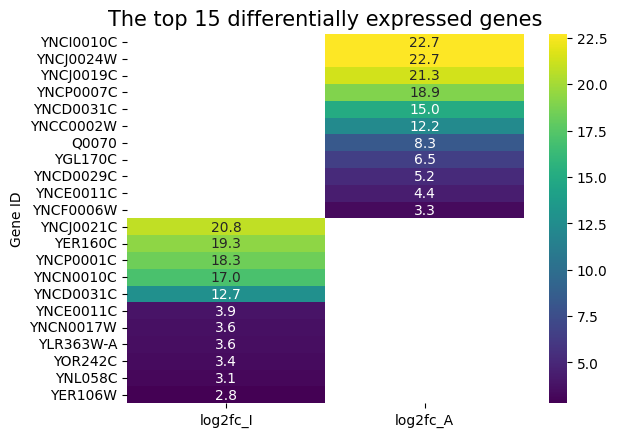

In [43]:
#Display a Heatmap of the top 15 differentially expressed genes, graph is annotated with log2fc data, 'fmt=".1f"' displays results to 1 decimal point, rather than rounded (Seaborn website).
sns.heatmap(MERGED[['log2fc_I', 'log2fc_A']].set_index(MERGED['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top 15 differentially expressed genes", fontsize = 15)
plt.ylabel("Gene ID", fontsize = 10)
plt.show()

,gene_id,baseMean,log2fc_I,lfcSE,pvalue,padj,Up/Down_Reg
4809,YNCJ0021C,58.65872,20.843440,4.192618,6.584422e-08,3.789926e-07,Up
1732,YER160C,250.22650,19.328230,1.875294,3.698023e-25,3.608702e-23,Up
4960,YNCP0001C,39.10949,18.323650,3.287516,5.998299e-09,4.254852e-08,Up
4919,YNCN0010C,19.64874,17.016730,5.900706,2.332409e-06,1.016802e-05,Up
4671,YNCD0031C,24.41078,12.743360,10.401688,4.515675e-05,1.554147e-04,Up
4685,YNCE0011C,2243.17100,3.885570,0.785515,6.706378e-10,5.517322e-09,Up
4926,YNCN0017W,18.95121,3.637113,7.094550,6.770765e-04,1.855962e-03,Up
4039,YLR363W-A,27.91767,3.562942,0.567571,3.028274e-13,4.595298e-12,Up
5779,YOR242C,31.56092,3.367956,0.395381,1.552633e-20,8.417392e-19,Up
5041,YNL058C,558.93230,3.121617,0.267326,3.381168e-34,1.128776e-31,Up


In [23]:
sorted_df2v = DF_I.rename(columns={'log2FoldChange': 'log2fc_I'})
sorted_df2v

,gene_id,baseMean,log2fc_I,lfcSE,pvalue,padj,Up/Down_Reg
0,Q0020,2846.323000,-2.302744,0.456351,2.566579e-08,1.602344e-07,Down
1,Q0045,4965.675000,-0.976205,0.873683,1.063241e-01,1.681830e-01,NotSign
2,Q0050,97393.600000,-2.984874,0.280593,7.808072e-29,1.500806e-26,Down
3,Q0055,9176.751000,-1.730134,0.378653,1.210130e-06,5.606908e-06,Down
4,Q0060,1104.390000,-1.085074,0.292156,1.203540e-04,3.849750e-04,Down
...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.657078,0.639239,1.914163e-03,4.733542e-03,Down
6393,YPR201W,6.547552,-0.893711,0.549416,6.413410e-02,1.083940e-01,NotSign
6394,YPR202W,1.681190,-0.731186,1.041286,2.028178e-01,2.924839e-01,NotSign
6395,YPR203W,0.983849,0.181616,1.145710,6.916343e-01,7.832595e-01,NotSign


In [19]:
sorted_dfA2v = DF_A.rename(columns={'log2FoldChange': 'log2fc_A'})
sorted_dfA2v

,gene_id,baseMean,log2fc_A,lfcSE,pvalue,padj,Up/Down_Reg,NegLog_Pval
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,NotSign,2.748946
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,Up,7.939172
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down,18.931102
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215,Down,502.919142
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01,NotSign,1.322081
...,...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03,Down,6.371621
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01,NotSign,0.453863
6394,YPR202W,1.681190,-0.323915,0.863129,4.037290e-01,5.250373e-01,NotSign,0.907011
6395,YPR203W,0.983849,0.025143,0.928803,9.337711e-01,NaN,NotSign,0.068524


In [12]:
MERGED2v = sorted_dfA2v.merge(sorted_df2v, on = 'gene_id')
MERGED2v


,gene_id,baseMean_x,log2fc_A,lfcSE_x,pvalue_x,padj_x,Up/Down_Reg_x,NegLog_Pval,baseMean_y,log2fc_I,lfcSE_y,pvalue_y,padj_y,Up/Down_Reg_y
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,NotSign,2.748946,2846.323000,-2.302744,0.456351,2.566579e-08,1.602344e-07,Down
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,Up,7.939172,4965.675000,-0.976205,0.873683,1.063241e-01,1.681830e-01,NotSign
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down,18.931102,97393.600000,-2.984874,0.280593,7.808072e-29,1.500806e-26,Down
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215,Down,502.919142,9176.751000,-1.730134,0.378653,1.210130e-06,5.606908e-06,Down
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01,NotSign,1.322081,1104.390000,-1.085074,0.292156,1.203540e-04,3.849750e-04,Down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03,Down,6.371621,11.660700,-1.657078,0.639239,1.914163e-03,4.733542e-03,Down
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01,NotSign,0.453863,6.547552,-0.893711,0.549416,6.413410e-02,1.083940e-01,NotSign
6394,YPR202W,1.681190,-0.323915,0.863129,4.037290e-01,5.250373e-01,NotSign,0.907011,1.681190,-0.731186,1.041286,2.028178e-01,2.924839e-01,NotSign
6395,YPR203W,0.983849,0.025143,0.928803,9.337711e-01,NaN,NotSign,0.068524,0.983849,0.181616,1.145710,6.916343e-01,7.832595e-01,NotSign


In [18]:
MERGED_log_asc = MERGED2v.sort_values(by=["log2fc_A", "log2fc_I", "padj_x", "padj_y"],
                             ascending=[False, False, True, True])
MERGED_log_asc = MERGED_log_asc.head(20)
MERGED_log_asc

,gene_id,baseMean_x,log2fc_A,lfcSE_x,pvalue_x,padj_x,Up/Down_Reg_x,NegLog_Pval,baseMean_y,log2fc_I,lfcSE_y,pvalue_y,padj_y,Up/Down_Reg_y
4785,YNCI0010C,46.892810,22.732160,4.071234,7.591811e-09,9.949354e-08,Up,18.696196,46.892810,0.068833,1.211288,8.519551e-01,9.114558e-01,NotSign
4812,YNCJ0024W,190.418800,22.699530,3.870816,1.676109e-09,2.559952e-08,Up,20.206791,190.418800,-0.143413,1.205044,7.085065e-01,7.969599e-01,NotSign
4807,YNCJ0019C,76.987810,21.335740,3.263297,2.798018e-11,6.558124e-10,Up,24.299525,76.987810,-0.373101,1.184485,3.972179e-01,5.073607e-01,NotSign
4966,YNCP0007C,27.806240,18.940570,7.824438,9.391192e-06,5.567113e-05,Up,11.575738,27.806240,0.071002,1.249060,8.184967e-01,8.844976e-01,NotSign
4671,YNCD0031C,24.410780,14.981760,10.070923,4.151034e-05,2.065012e-04,Up,10.089568,24.410780,12.743360,10.401688,4.515675e-05,1.554147e-04,Up
4629,YNCC0002W,23.861640,12.229320,10.553447,8.310560e-05,3.805000e-04,Up,9.395398,23.861640,0.062527,1.263785,8.257872e-01,8.896006e-01,NotSign
6,Q0070,3004.823000,8.290317,0.396236,5.151415e-100,1.569636e-96,Up,228.619238,3004.823000,-0.735213,0.275909,5.937684e-03,1.312290e-02,Down
2056,YGL170C,184.479300,6.465401,0.556847,7.422143e-34,2.512808e-31,Up,76.283425,184.479300,0.883015,0.297208,2.057274e-03,5.067390e-03,Up
4669,YNCD0029C,43.608500,5.166352,9.222832,NaN,NaN,NotSign,NaN,43.608500,0.080039,1.296001,NaN,NaN,NotSign
4685,YNCE0011C,2243.171000,4.364310,0.789312,2.131781e-11,5.155189e-10,Up,24.571478,2243.171000,3.885570,0.785515,6.706378e-10,5.517322e-09,Up


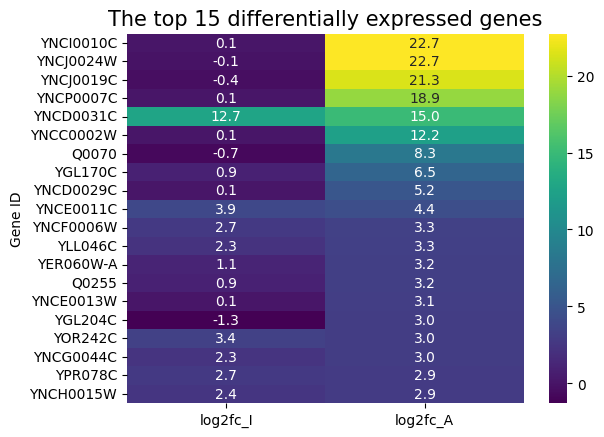

In [14]:
#Display a Heatmap of the top 15 differentially expressed genes, graph is annotated with log2fc data, 'fmt=".1f"' displays results to 1 decimal point, rather than rounded (Seaborn website).
sns.heatmap(MERGED_log_asc[['log2fc_I', 'log2fc_A']].set_index(MERGED_log_asc['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top 15 differentially expressed genes", fontsize = 15)
plt.ylabel("Gene ID", fontsize = 10)
plt.show()

In [25]:
MERGED_log_asc1 = MERGED_log_asc.sort_values(by=["log2fc_I", "padj_y"],
                             ascending=[False, True])
MERGED_log_asc1

,gene_id,baseMean_x,log2fc_A,lfcSE_x,pvalue_x,padj_x,Up/Down_Reg_x,NegLog_Pval,baseMean_y,log2fc_I,lfcSE_y,pvalue_y,padj_y,Up/Down_Reg_y
4671,YNCD0031C,24.410780,14.981760,10.070923,4.151034e-05,2.065012e-04,Up,10.089568,24.410780,12.743360,10.401688,4.515675e-05,1.554147e-04,Up
4685,YNCE0011C,2243.171000,4.364310,0.789312,2.131781e-11,5.155189e-10,Up,24.571478,2243.171000,3.885570,0.785515,6.706378e-10,5.517322e-09,Up
5779,YOR242C,31.560920,2.998969,0.360601,2.673386e-19,2.585970e-17,Up,42.765771,31.560920,3.367956,0.395381,1.552633e-20,8.417392e-19,Up
6276,YPR078C,11.986190,2.895469,0.565272,7.312840e-10,1.231062e-08,Up,21.036219,11.986190,2.709269,0.523326,2.863276e-09,2.124182e-08,Up
4705,YNCF0006W,33.385760,3.314164,7.360879,NaN,NaN,NotSign,NaN,33.385760,2.678388,6.253659,NaN,NaN,NotSign
4774,YNCH0015W,7.814198,2.861007,0.933065,5.036173e-06,3.240806e-05,Up,12.198864,7.814198,2.441479,0.769077,3.708089e-05,1.297367e-04,Up
4756,YNCG0044C,1627.212000,2.997390,0.739428,1.037997e-07,1.043820e-06,Up,16.080803,1627.212000,2.303587,0.651434,1.742919e-05,6.466038e-05,Up
3664,YLL046C,58.127380,3.298596,0.358751,1.400958e-22,1.940327e-20,Up,50.319716,58.127380,2.263862,0.311461,2.781338e-14,5.040579e-13,Up
1628,YER060W-A,79.194160,3.215959,0.398738,2.333155e-18,2.031178e-16,Up,40.599310,79.194160,1.084267,0.333223,6.607458e-04,1.815119e-03,Up
19,Q0255,1065.918000,3.165602,0.450088,5.570116e-15,2.672779e-13,Up,32.821361,1065.918000,0.911097,0.408238,1.673213e-02,3.299095e-02,Up


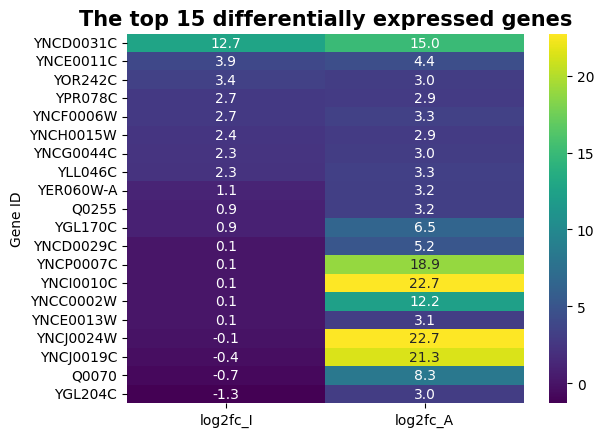

In [16]:
#Display a Heatmap of the top 15 differentially expressed genes, graph is annotated with log2fc data, 'fmt=".1f"' displays results to 1 decimal point, rather than rounded (Seaborn website).
sns.heatmap(MERGED_log_asc1[['log2fc_I', 'log2fc_A']].set_index(MERGED_log_asc1['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top 15 differentially expressed genes", fontsize = 15, weight = "bold")
plt.ylabel("Gene ID", fontsize = 10)
plt.show()

In [27]:
DF_A

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg,NegLog_Pval
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,NotSign,2.748946
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,Up,7.939172
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down,18.931102
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215,Down,502.919142
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01,NotSign,1.322081
...,...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03,Down,6.371621
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01,NotSign,0.453863
6394,YPR202W,1.681190,-0.323915,0.863129,4.037290e-01,5.250373e-01,NotSign,0.907011
6395,YPR203W,0.983849,0.025143,0.928803,9.337711e-01,NaN,NotSign,0.068524


In [22]:
DFA3v = DF_A.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
DFA3v = DFA3v.head(100)

In [23]:
DFI3v = DF_I.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
DFI3v = DFI3v.head(100)

In [24]:
DFA3v = DFA3v.rename(columns={'log2FoldChange': 'log2fc_A'})
DFI3v = DFI3v.rename(columns={'log2FoldChange': 'log2fc_I'})

MERGED3v = pd.concat([DFA3v, DFI3v], ignore_index=True)
MERGED3v

,gene_id,baseMean,log2fc_A,lfcSE,pvalue,padj,Up/Down_Reg,log2fc_I
0,YNCI0010C,46.89281,22.73216,4.071234,7.591811e-09,9.949354e-08,Up,NaN
1,YNCJ0024W,190.41880,22.69953,3.870816,1.676109e-09,2.559952e-08,Up,NaN
2,YNCJ0019C,76.98781,21.33574,3.263297,2.798018e-11,6.558124e-10,Up,NaN
3,YNCP0007C,27.80624,18.94057,7.824438,9.391192e-06,5.567113e-05,Up,NaN
4,YNCD0031C,24.41078,14.98176,10.070923,4.151034e-05,2.065012e-04,Up,NaN
...,...,...,...,...,...,...,...,...
195,YNL175C,249.86380,NaN,0.348030,2.991390e-11,3.151892e-10,Up,2.187731
196,YPL226W,246.27280,NaN,0.258417,2.772450e-18,9.609645e-17,Up,2.185487
197,YGL183C,31.85760,NaN,0.438537,5.264561e-08,3.086239e-07,Up,2.183956
198,YOR127W,393.92370,NaN,0.166685,3.987758e-40,2.767475e-37,Up,2.182271


In [132]:
MERGED3v = MERGED3v.sort_values(by=["log2fc_A", "log2fc_I", "padj"],
                             ascending=[False, False, True])
MERGED3v

,gene_id,baseMean,log2fc_A,lfcSE,pvalue,padj,Up/Down_Reg,NegLog_Pval,log2fc_I
0,YNCI0010C,46.89281,22.732160,4.071234,7.591811e-09,9.949354e-08,Up,18.696196,NaN
1,YNCJ0024W,190.41880,22.699530,3.870816,1.676109e-09,2.559952e-08,Up,20.206791,NaN
2,YNCJ0019C,76.98781,21.335740,3.263297,2.798018e-11,6.558124e-10,Up,24.299525,NaN
3,YNCP0007C,27.80624,18.940570,7.824438,9.391192e-06,5.567113e-05,Up,11.575738,NaN
4,YNCD0031C,24.41078,14.981760,10.070923,4.151034e-05,2.065012e-04,Up,10.089568,NaN
5,YNCC0002W,23.86164,12.229320,10.553447,8.310560e-05,3.805000e-04,Up,9.395398,NaN
6,Q0070,3004.82300,8.290317,0.396236,5.151415e-100,1.569636e-96,Up,228.619238,NaN
7,YGL170C,184.47930,6.465401,0.556847,7.422143e-34,2.512808e-31,Up,76.283425,NaN
8,YNCD0029C,43.60850,5.166352,9.222832,NaN,NaN,NotSign,NaN,NaN
9,YNCE0011C,2243.17100,4.364310,0.789312,2.131781e-11,5.155189e-10,Up,24.571478,NaN


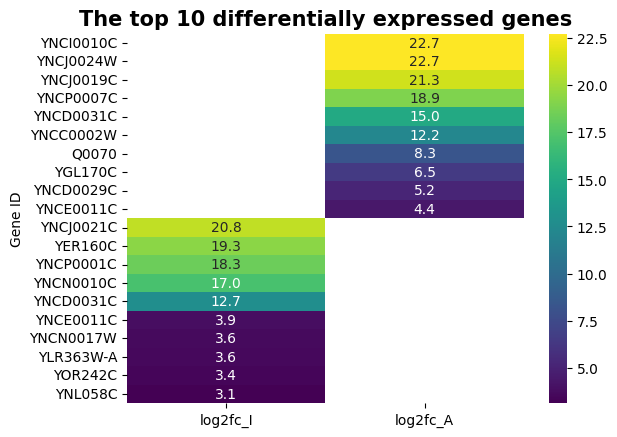

In [133]:
#Display a Heatmap of the top 15 differentially expressed genes, graph is annotated with log2fc data, 'fmt=".1f"' displays results to 1 decimal point, rather than rounded (Seaborn website).
sns.heatmap(MERGED3v[['log2fc_I', 'log2fc_A']].set_index(MERGED3v['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top 10 differentially expressed genes", fontsize = 15, weight = "bold")
plt.ylabel("Gene ID", fontsize = 10)
plt.show()

In [25]:
DFA3v = DFA3v.rename(columns={'log2FoldChange': 'log2fc_A'})
DFI3v = DFI3v.rename(columns={'log2FoldChange': 'log2fc_I'})
MERGED4v = DFA3v.merge(DFI3v, on = 'gene_id')
MERGED4v

,gene_id,baseMean_x,log2fc_A,lfcSE_x,pvalue_x,padj_x,Up/Down_Reg_x,baseMean_y,log2fc_I,lfcSE_y,pvalue_y,padj_y,Up/Down_Reg_y
0,YNCD0031C,24.410780,14.981760,10.070923,4.151034e-05,2.065012e-04,Up,24.410780,12.743360,10.401688,4.515675e-05,1.554147e-04,Up
1,YNCE0011C,2243.171000,4.364310,0.789312,2.131781e-11,5.155189e-10,Up,2243.171000,3.885570,0.785515,6.706378e-10,5.517322e-09,Up
2,YLL046C,58.127380,3.298596,0.358751,1.400958e-22,1.940327e-20,Up,58.127380,2.263862,0.311461,2.781338e-14,5.040579e-13,Up
3,YOR242C,31.560920,2.998969,0.360601,2.673386e-19,2.585970e-17,Up,31.560920,3.367956,0.395381,1.552633e-20,8.417392e-19,Up
4,YNCG0044C,1627.212000,2.997390,0.739428,1.037997e-07,1.043820e-06,Up,1627.212000,2.303587,0.651434,1.742919e-05,6.466038e-05,Up
5,YPR078C,11.986190,2.895469,0.565272,7.312840e-10,1.231062e-08,Up,11.986190,2.709269,0.523326,2.863276e-09,2.124182e-08,Up
6,YNCH0015W,7.814198,2.861007,0.933065,5.036173e-06,3.240806e-05,Up,7.814198,2.441479,0.769077,3.708089e-05,1.297367e-04,Up
7,YDR218C,52.217050,2.694031,0.354460,7.958050e-17,5.449029e-15,Up,52.217050,2.271946,0.326875,2.673142e-13,4.105506e-12,Up
8,YDR446W,9.910044,2.626845,0.607196,4.988671e-08,5.352282e-07,Up,9.910044,2.726958,0.594644,5.198140e-08,3.050120e-07,Up
9,YLR121C,346.380700,2.612597,0.462582,4.992197e-11,1.098283e-09,Up,346.380700,2.762443,0.445123,5.799735e-12,6.863381e-11,Up


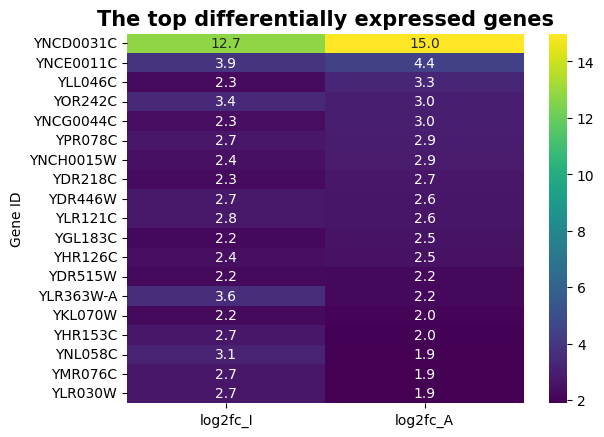

In [54]:
#Display a Heatmap of the top 15 differentially expressed genes, graph is annotated with log2fc data, 'fmt=".1f"' displays results to 1 decimal point, rather than rounded (Seaborn website).
sns.heatmap(MERGED4v[['log2fc_I', 'log2fc_A']].set_index(MERGED4v['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top differentially expressed genes", fontsize = 15, weight = "bold")
plt.ylabel("Gene ID", fontsize = 10)
plt.show()

In [27]:
DF_I

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
0,Q0020,2846.323000,-2.302744,0.456351,2.566579e-08,1.602344e-07,Down
1,Q0045,4965.675000,-0.976205,0.873683,1.063241e-01,1.681830e-01,NotSign
2,Q0050,97393.600000,-2.984874,0.280593,7.808072e-29,1.500806e-26,Down
3,Q0055,9176.751000,-1.730134,0.378653,1.210130e-06,5.606908e-06,Down
4,Q0060,1104.390000,-1.085074,0.292156,1.203540e-04,3.849750e-04,Down
...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.657078,0.639239,1.914163e-03,4.733542e-03,Down
6393,YPR201W,6.547552,-0.893711,0.549416,6.413410e-02,1.083940e-01,NotSign
6394,YPR202W,1.681190,-0.731186,1.041286,2.028178e-01,2.924839e-01,NotSign
6395,YPR203W,0.983849,0.181616,1.145710,6.916343e-01,7.832595e-01,NotSign


In [32]:
DF_A

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,NotSign
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,Up
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215,Down
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01,NotSign
...,...,...,...,...,...,...,...
6390,YPR198W,143.394600,-2.122686,0.235922,1.977200e-21,2.409812e-19,Down
6391,YPR199C,64.329290,-0.278093,0.240946,2.286189e-01,3.381869e-01,NotSign
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03,Down
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01,NotSign


In [5]:
DF_A

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,NotSign
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,Up
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215,Down
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01,NotSign
...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03,Down
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01,NotSign
6394,YPR202W,1.681190,-0.323915,0.863129,4.037290e-01,5.250373e-01,NotSign
6395,YPR203W,0.983849,0.025143,0.928803,9.337711e-01,NaN,NotSign


In [18]:
DF_A = DF_A.dropna()
DF_A

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,NotSign
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,Up
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215,Down
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01,NotSign
...,...,...,...,...,...,...,...
6390,YPR198W,143.394600,-2.122686,0.235922,1.977200e-21,2.409812e-19,Down
6391,YPR199C,64.329290,-0.278093,0.240946,2.286189e-01,3.381869e-01,NotSign
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03,Down
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01,NotSign


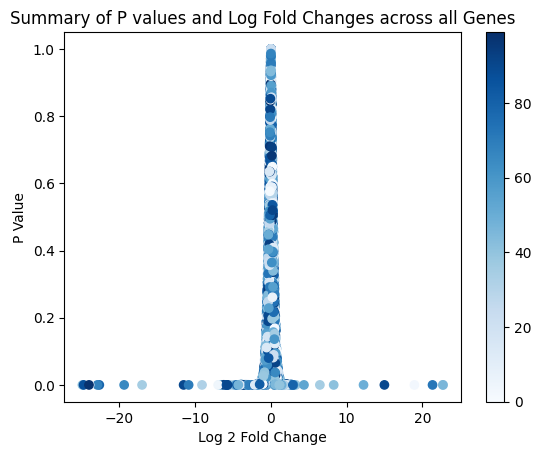

In [31]:
x = (DF_A['log2FoldChange'])
y = (DF_A['pvalue'])
colors = np.random.randint(100, size = len(DF_A))
plt.scatter(x, y, c = colors, cmap = 'Blues')
plt.colorbar()
plt.xlabel("Log 2 Fold Change", fontsize=10)
plt.ylabel("P Value", fontsize=10)
plt.title("Summary of P values and Log Fold Changes across all Genes")
plt.show()


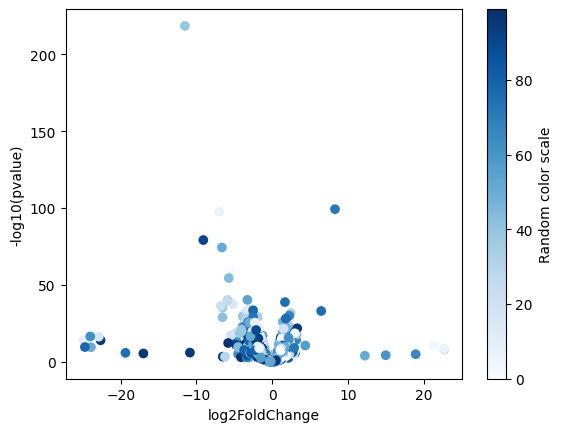

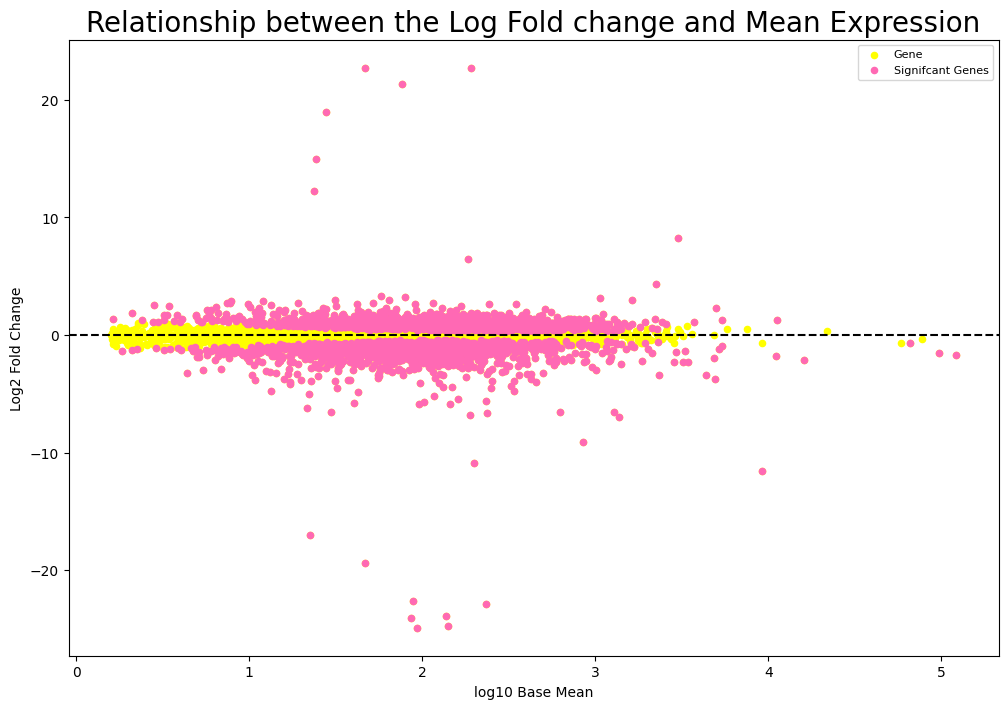

In [36]:
DF_A['Log_BaseMean'] = np.log10(DF_A['baseMean'])
plt.figure(figsize = (12, 8))
plt.scatter(DF_A['Log_BaseMean'], DF_A['log2FoldChange'],
            color = 'yellow', s = 20, label = 'Gene')
plt.scatter(DF_A.loc[DF_A['padj'] < 0.05, 'Log_BaseMean'],
            DF_A.loc[DF_A['padj'] < 0.05, 'log2FoldChange'],
            color = 'hotpink', s = 20, label = 'Signifcant Genes')
plt.title("Relationship between the Log Fold change and Mean Expression", fontsize = 20)
plt.xlabel("log10 Base Mean", fontsize = 10)
plt.ylabel("Log2 Fold Change", fontsize = 10)
plt.axhline(0, ls = '--', color = 'black')
plt.legend(loc = 'upper right', fontsize = 8)
plt.show()

In [31]:
DF_A = DF_A.dropna()
DF_A

DF_I = DF_I.dropna()
DF_I

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
0,Q0020,2846.323000,-2.302744,0.456351,2.566579e-08,1.602344e-07,Down
1,Q0045,4965.675000,-0.976205,0.873683,1.063241e-01,1.681830e-01,NotSign
2,Q0050,97393.600000,-2.984874,0.280593,7.808072e-29,1.500806e-26,Down
3,Q0055,9176.751000,-1.730134,0.378653,1.210130e-06,5.606908e-06,Down
4,Q0060,1104.390000,-1.085074,0.292156,1.203540e-04,3.849750e-04,Down
...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.657078,0.639239,1.914163e-03,4.733542e-03,Down
6393,YPR201W,6.547552,-0.893711,0.549416,6.413410e-02,1.083940e-01,NotSign
6394,YPR202W,1.681190,-0.731186,1.041286,2.028178e-01,2.924839e-01,NotSign
6395,YPR203W,0.983849,0.181616,1.145710,6.916343e-01,7.832595e-01,NotSign


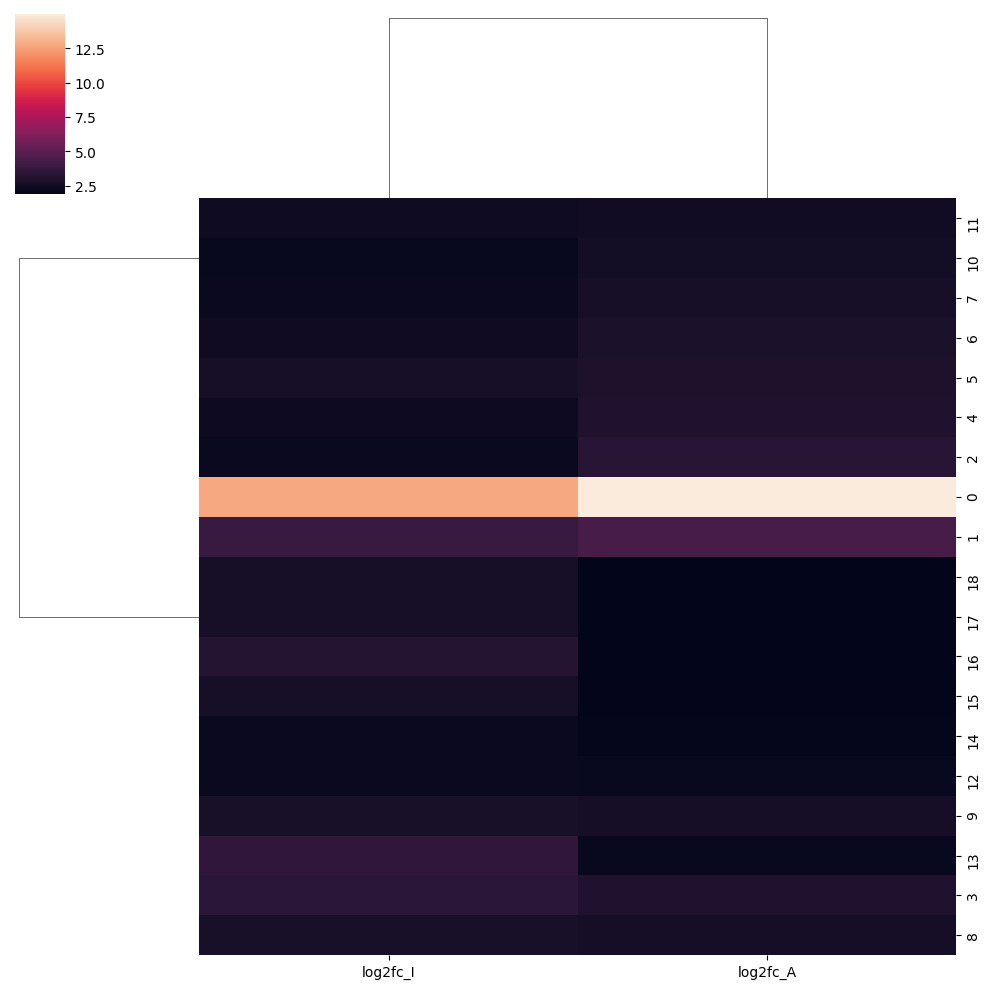

In [35]:
sns.clustermap(MERGED4v[['log2fc_I', 'log2fc_A']], metric="correlation", method="single")

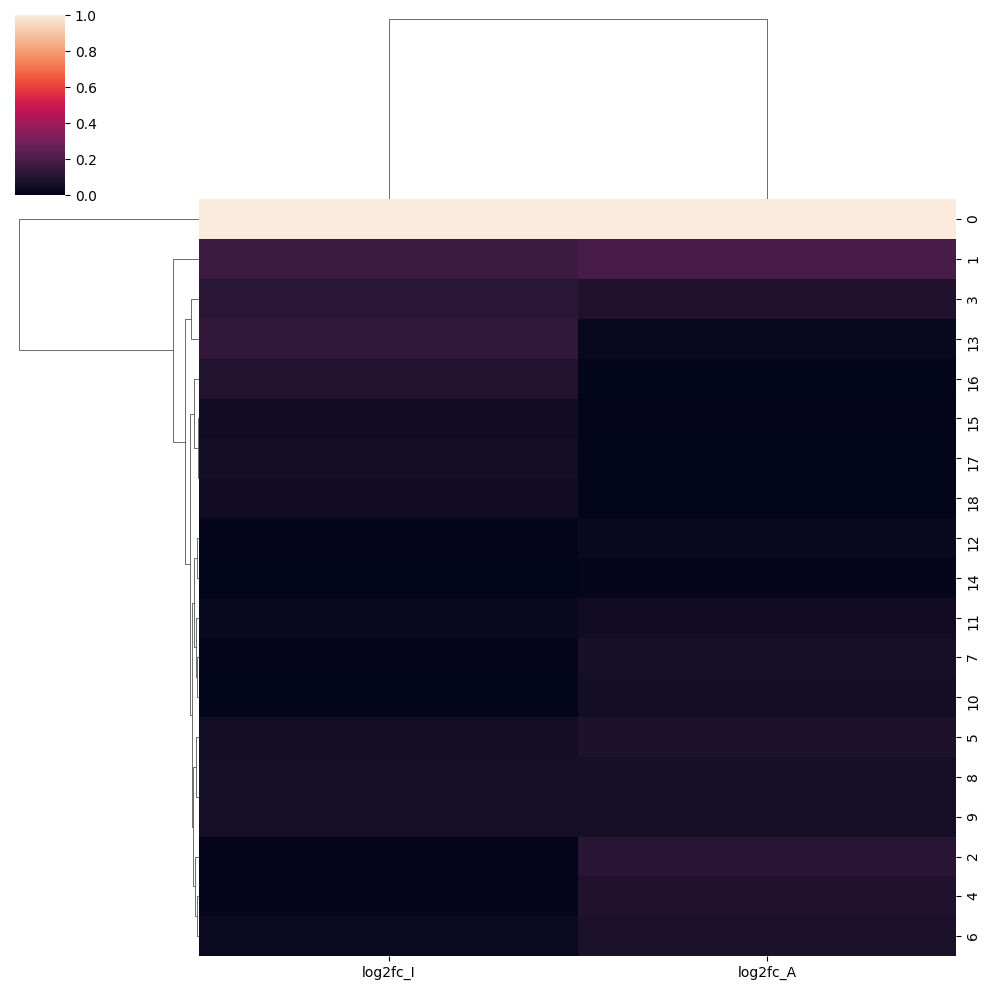

In [36]:
sns.clustermap(MERGED4v[['log2fc_I', 'log2fc_A']], standard_scale=1)

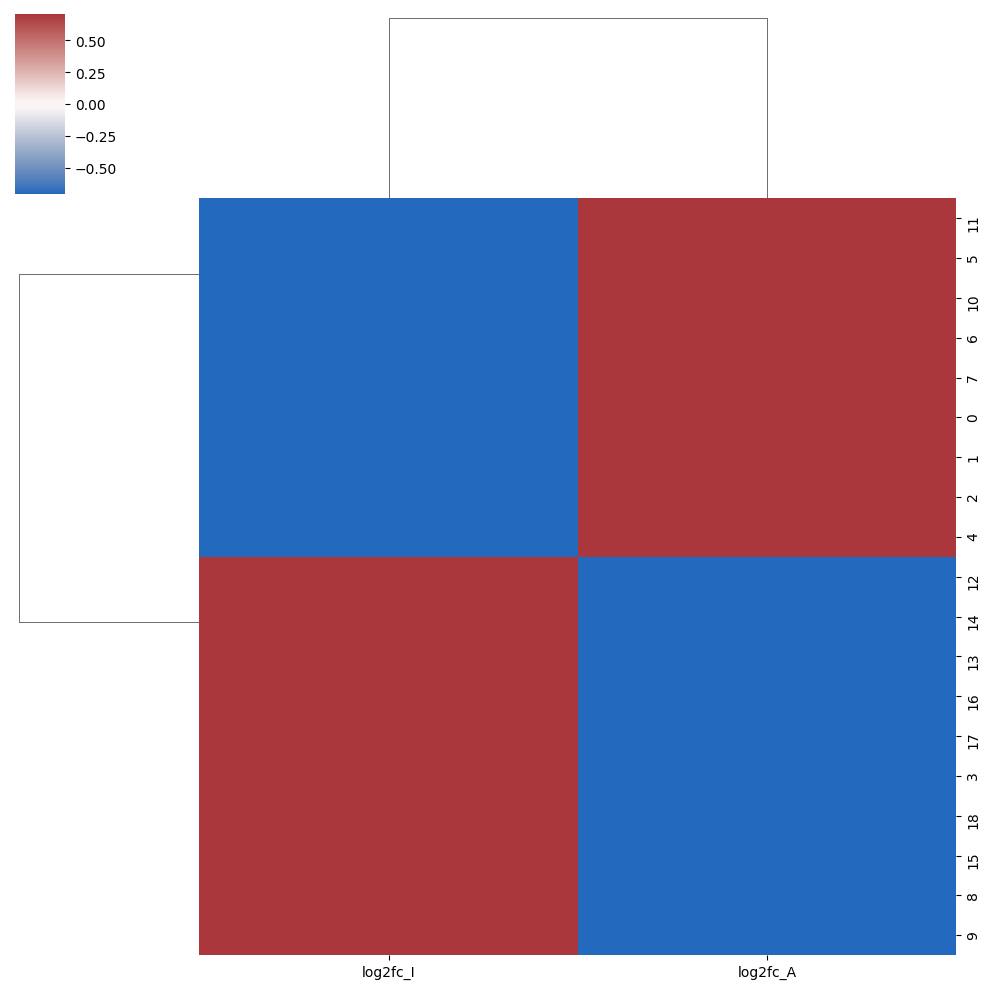

In [38]:
sns.clustermap(MERGED4v[['log2fc_I', 'log2fc_A']],z_score=0, cmap="vlag", center=0)

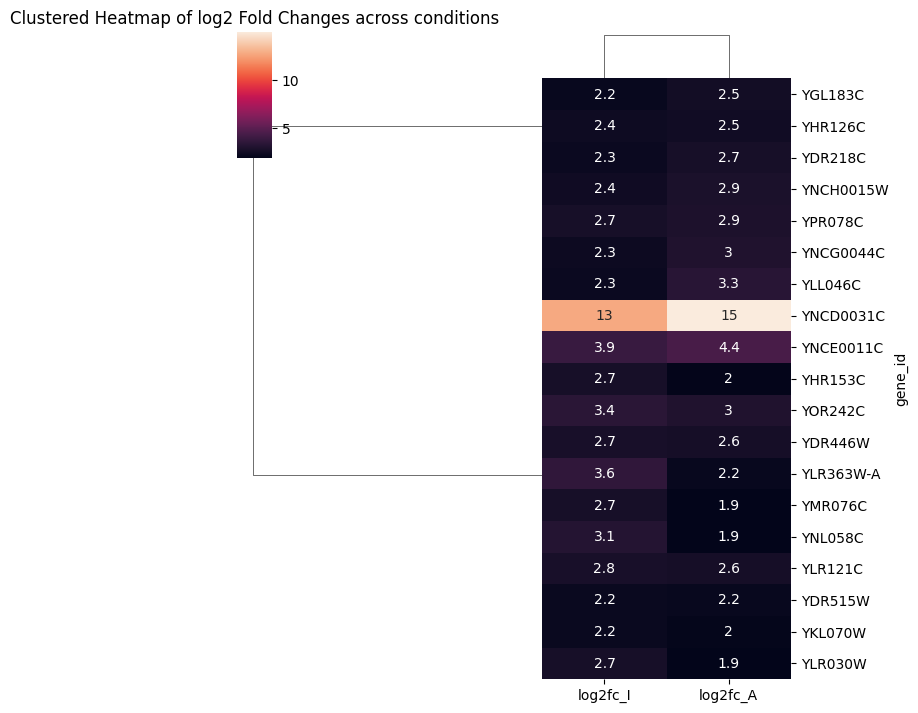

In [121]:
sns.clustermap(MERGED4v[['log2fc_I', 'log2fc_A']].set_index(MERGED4v['gene_id']), 
            metric="correlation", annot=True, figsize=(7,7), dendrogram_ratio=(0.55, 0.07))
plt.title("Clustered Heatmap of log2 Fold Changes across conditions")

plt.show()



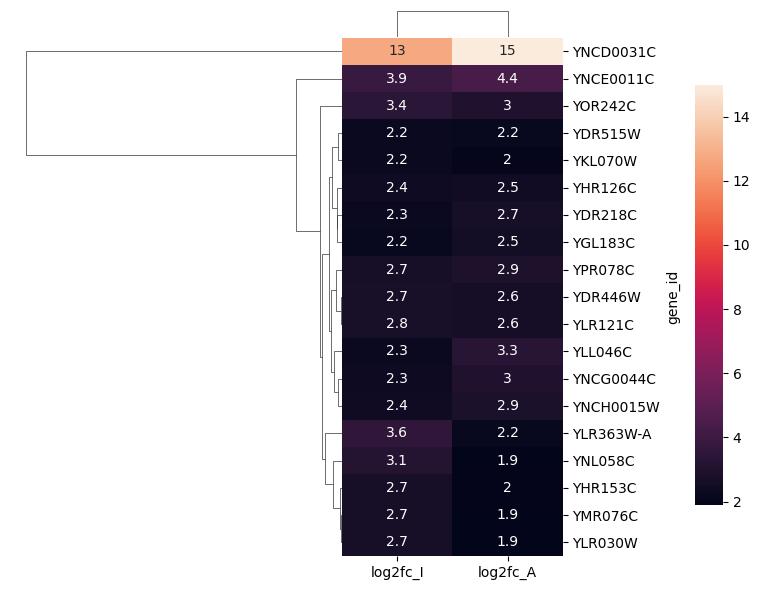

In [153]:
sns.clustermap(MERGED4v[['log2fc_I', 'log2fc_A']].set_index(MERGED4v['gene_id']), 
            annot=True, figsize=(7,6), dendrogram_ratio=(.6, .05), cbar_pos=(1, .15, .04, .7))
plt.show()
